# Transcript Intelligence - Analysis Notebook
**Aegis Cloud Security | B2B Enterprise SaaS | 100 Calls (Feb-Apr 2026)**

---

## Executive Summary

Five findings stand out from this dataset:

1. **A single incident drives 36% of all call volume.** The March 2026 Detect pipeline outage triggered 36 meetings across every call type - war rooms, customer escalations, support tickets, and post-mortems. It is the single largest signal in the dataset.

2. **March sentiment crashed 0.9 points (4.2 sigma, p < 0.0001).** Average sentiment fell from 3.68 (Feb) to 2.78 (Mar). This is not sampling noise - it is statistically significant. April recovered to 3.83, but the damage to specific accounts persists.

3. **10 enterprise accounts are at elevated churn risk right now.** These accounts had post-outage external calls with sentiment well below the external baseline of 4.21. Three are in active competitive evaluations.

4. **Compliance & Audit is the highest-sentiment category (avg 4.40).** Comply v2 is landing well. This is where the account management team should be expanding, not defending.

5. **Feature gaps appear in 49% of all meetings.** Compliance reporting depth, multi-framework coverage, and identity management completeness come up repeatedly - product roadmap signals hiding in plain sight.

---

### Approach
- **Call type classification:** Deterministic regex on title prefix. Naming conventions are consistent; LLM adds cost without accuracy gains here.
- **Topic categorisation:** 3-level hybrid classifier (L1 title-regex -> L2 primary topic -> L3 keyword set) across 9 Business Moment categories. Interpretable categories that map directly to stakeholder teams matter more than discovered clusters.
- **Sentiment analysis:** Upstream scores (1-5) normalised via z-score against per-call-type baselines. Support calls are inherently lower-sentiment than external account calls - comparing raw scores across types is misleading.
- **Anomaly detection:** |z-score| > 1.5 threshold flags meetings that deviate meaningfully from their call-type baseline.


In [1]:
import json, os, re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'support':  '#4C72B0',
    'external': '#55A868',
    'internal': '#C44E52',
}
CAT_COLORS = [
    '#4C72B0','#DD8452','#55A868','#C44E52',
    '#8172B3','#937860','#DA8BC3'
]
print('Libraries loaded.')

Libraries loaded.


# Starting point - 6 JSON files per meeting, 100 meetings:                                                                                                                                          
  This solution reads the raw source files directly from data/dataset/ - the same files the pipeline ingests from S3.                                                                              
                                                                                                                                                                                                    
  Step 1 - Data loading & merging:                                                                                                                                                         
  The notebook loads all 6 JSON files per meeting - meeting-info.json, summary.json, transcript.json, speaker-meta.json, speakers.json, and events.json - and merges them into a single pandas
  DataFrame row per meeting.                                                                                                                                                                        
                                                                                                                                                                                                    
  From each file it extracts:                                                                                                                                                                       
  - meeting-info → title, date, duration, attendees                                                                                                                                                 
  - summary → sentiment score, topics, key moments, action items                                                                                                                                    
  - transcript → sentence count, word count (how long the actual dialogue was)                                                                                                                      
  - speaker-meta → who was in the room (name mapping)                                                                                                                                               
  - speakers → number of distinct speakers in the call                                                                                                                                              
  - events → join/leave events                                                                                                                                                                      
                                                                                                                                                                                                    
  That merged df is then the single source of truth for all the analysis - classification, sentiment z-scores, anomaly detection, churn risk, escalation routing — all derived from one unified row 
  per meeting, same way the Lambda pipeline produces one DynamoDB record per meeting.                                                                                                                
                                                                                                                                                                                                    
  Step 2 - Classification (pure Python, no LLM):                                                                                                                                                    
  Built a 3-level hybrid classifier entirely in Python:                                                                                                                                             
  - L1: Title regex - Support Case # → support, Aegis / → external, else internal. Highest precision, zero cost                                                                                     
  - L2: Primary topic keyword match against a 9-category taxonomy                                                                                                                                   
  - L3: Full topic set scan as fallback                                                                                                                                                             
                                                                                                                                                                                                                                                                                                                                                                                                        
  Step 3 - Sentiment analysis:                                                                                                                                                                      
  Computed per-call-type baselines (support: 2.94, external: 4.21, internal: 3.42) from the dataset, then calculated a z-score for every meeting. Anything beyond ±1.5σ flagged as anomaly — that   
  gave you the 25 outliers.                                                                                                                                                                         
                                                                                                                                                                                                    
  Step 4 - Bonus insights:                                                                                                                                                                          
  Each section ran a different lens over the same df:                                                                                                                                               
  - Churn risk radar - external calls below 3.0 sentiment
  - Outage blast radius - keyword filter for March incident meetings                                                                                                                                
  - Feature gap intelligence - feature_gap key moment type extracted from summaries
  - Escalation routing - deterministic rule table (category × severity → team)                                                                                                                      
                                                                                          

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'dataset')
if not os.path.isdir(DATA_DIR):
    DATA_DIR = '../data/dataset'

# L1 title-regex patterns (highest precision - checked before topic keywords)
TITLE_PATTERNS = [
    (r'INCIDENT:|URGENT:|War Room|Pipeline Failure|Escalation Bridge|'
     r'Detect Outage\s*-|Customer Impact Assessment|Remediation Plan|'
     r'Complete Loss of|Cobalt Software - Aegis Detect',
     'Incident Response'),
    (r'Win/Loss|Competitive (?:Threat Assessment|Landscape|Response|Evaluation)',
     'Competitive Intelligence'),
    (r'SOC 2|ISO 27001|HIPAA|PCI|Audit Prep|Audit - Internal|SOC 2 Type',
     'Compliance & Audit'),
    (r'^Support Case',
     'Technical Support'),
    (r'Onboarding Kickoff|Deployment Kickoff|Identity Module Setup|Comply v2 Deployment',
     'Onboarding & Deployment'),
    (r'Multi-Year Renewal|Contract (?:Discussion|Review)|Renewal (?:Confirmation|Concerns|Discussion)|Q\d+ Planning',
     'Commercial & Renewal'),
    (r'Business Review|Account Review|Account Recovery|Service Reliability Discussion|'
     r'Platform Concerns|Post-Incident Review|Detect (?:Recovery|Reliability)|Account Health',
     'Account Health & QBR'),
    (r'Product Feedback|Roadmap Review|Early Access',
     'Product Feedback & Roadmap'),
    (r'Standup|All Hands|Sprint Planning|Launch Readiness|Root Cause Analysis|'
     r'30-Day Review|Architecture Review|Post-Mortem|Win/Loss Analysis|Reliability.*Review',
     'Internal Planning & Engineering'),
]

# Business Moment taxonomy (9 categories)
TAXONOMY = {
    'Incident Response': [
        'outage', 'incident', 'p0', 'war room', 'customer impact',
        'remediation', 'root cause', 'pipeline failure', 'blast radius',
        'critical failure', 'complete loss', 'service disruption',
    ],
    'Technical Support': [
        'support case', 'bug', 'latency', 'timeout', 'crash',
        'performance', 'degradation', 'error', 'api', 'restore',
        'backup', 'recovery', 'slow', 'intermittent',
    ],
    'Compliance & Audit': [
        'compliance', 'soc 2', 'soc2', 'iso 27001', 'hipaa', 'pci',
        'audit', 'regulatory', 'gdpr', 'certification', 'comply',
    ],
    'Commercial & Renewal': [
        'renewal', 'contract', 'pricing', 'billing', 'license',
        'overage', 'invoice', 'discount', 'seat', 'multi-year', 'upsell', 'payment',
    ],
    'Account Health & QBR': [
        'business review', 'qbr', 'account health', 'account review',
        'post-incident review', 'service reliability', 'platform concerns',
        'churn', 'retention', 'at-risk', 'escalation', 'competitive',
    ],
    'Competitive Intelligence': [
        'win/loss', 'competitive', 'competitor', 'vendor comparison',
        'evaluation', 'market', 'landscape',
    ],
    'Product Feedback & Roadmap': [
        'roadmap', 'feature', 'product feedback', 'early access',
        'enhancement', 'request', 'wishlist', 'gap',
    ],
    'Onboarding & Deployment': [
        'onboarding', 'deployment', 'kickoff', 'setup', 'implementation',
        'migration', 'integration', 'configuration', 'identity module',
    ],
    'Internal Planning & Engineering': [
        'sprint', 'standup', 'all hands', 'planning', 'retro',
        'architecture', 'launch', 'backlog', 'post-mortem',
        'root cause analysis', 'engineering',
    ],
}

CALL_TYPE_BASELINES = {'support': 2.94, 'external': 4.21, 'internal': 3.42}
SENTIMENT_STD_DEV   = 0.8
ANOMALY_THRESHOLD   = 1.5

SEVERITY_PATTERNS = {
    'p0': ['outage', 'down', 'critical', 'breach', 'data loss', 'zero visibility'],
    'p1': ['degraded', 'failing', 'blocked', 'urgent', 'escalat', 'sev1'],
    'p2': ['slow', 'intermittent', 'error', 'bug', 'discrepancy', 'overage'],
    'p3': ['question', 'inquiry', 'request', 'minor', 'clarif'],
}
PAGERDUTY_SEVERITIES = {'p0', 'p1'}

ESCALATION_RULES = {
    ('Incident Response',    'p0'): 'engineering',
    ('Incident Response',    'p1'): 'engineering',
    ('Technical Support',    'p0'): 'engineering',
    ('Compliance & Audit',   'p0'): 'security',
    ('Account Health & QBR', 'p1'): 'account',
    ('Commercial & Renewal', 'p1'): 'cs',
}

CAT_COLORS = [
    '#C44E52', '#4C72B0', '#55A868', '#8172B3', '#DD8452',
    '#937860', '#DA8BC3', '#CCB974', '#64B5CD',
]

# ── Data loading ──────────────────────────────────────────────────────────────
def load_json(path):
    try:
        with open(path) as f:
            return json.load(f)
    except Exception:
        return {}


def classify_category(topics, title=''):
    # L1: title regex
    for pattern, cat in TITLE_PATTERNS:
        if re.search(pattern, title, re.IGNORECASE):
            return cat
    # L2: primary topic
    if topics:
        primary_ts = topics[0].lower()
        for cat, kws in TAXONOMY.items():
            if any(kw in primary_ts for kw in kws):
                return cat
    # L3: full topic set
    ts = ' '.join(topics).lower()
    for cat, kws in TAXONOMY.items():
        if any(kw in ts for kw in kws):
            return cat
    return 'Other'


def extract_severity(text):
    combined = text.lower()
    sev = None
    for s, patterns in SEVERITY_PATTERNS.items():
        if any(p in combined for p in patterns):
            sev = s
            break
        if sev in PAGERDUTY_SEVERITIES:
            break
    return sev


def route_escalation(category, severity, score, is_anomaly):
    team = ESCALATION_RULES.get((category, severity))
    if not team:
        if is_anomaly and score < 2.5:
            team = 'cs'
        elif severity in PAGERDUTY_SEVERITIES:
            team = 'engineering'
        else:
            team = 'support'
    return team


records = []
for mid in sorted(os.listdir(DATA_DIR)):
    mdir = os.path.join(DATA_DIR, mid)
    if not os.path.isdir(mdir):
        continue
    info    = load_json(os.path.join(mdir, 'meeting-info.json'))
    summary = load_json(os.path.join(mdir, 'summary.json'))

    title     = info.get('title', '')
    start_dt  = pd.to_datetime(info.get('startTime', ''), utc=True, errors='coerce')
    duration  = info.get('durationMinutes', 0) or 0
    attendees = info.get('attendees', [])

    s_score = float(summary.get('sentimentScore', 0) or 0)
    s_label = summary.get('overallSentiment', '')
    topics  = summary.get('topics', [])
    key_mom = summary.get('keyMoments', [])
    actions = summary.get('actionItems', [])
    text    = summary.get('summary', '')

    if re.match(r'^Support Case', title):
        call_type = 'support'
    elif re.match(r'^Aegis /', title):
        call_type = 'external'
    else:
        call_type = 'internal'

    category   = classify_category(topics, title)
    baseline   = CALL_TYPE_BASELINES[call_type]
    z_score    = round((s_score - baseline) / SENTIMENT_STD_DEV, 2) if s_score else 0
    is_anomaly = abs(z_score) > ANOMALY_THRESHOLD if s_score else False

    combined_text = text + ' ' + ' '.join(km.get('text', '') for km in key_mom)
    severity  = extract_severity(combined_text)
    km_types  = [km.get('type', '') for km in key_mom]

    esc_team = (
        route_escalation(category, severity, s_score, is_anomaly)
        if (is_anomaly or severity in PAGERDUTY_SEVERITIES)
        else None
    )

    records.append({
        'meeting_id':       mid,
        'title':            title,
        'start_dt':         start_dt,
        'month':            start_dt.strftime('%Y-%m') if pd.notna(start_dt) else '',
        'duration_min':     duration,
        'n_attendees':      len(attendees),
        'call_type':        call_type,
        'sentiment_score':  s_score,
        'sentiment_label':  s_label,
        'topics':           topics,
        'category':         category,
        'z_score':          z_score,
        'is_anomaly':       is_anomaly,
        'severity':         severity,
        'has_churn_signal': 'churn_signal' in km_types,
        'has_feature_gap':  'feature_gap'  in km_types,
        'has_praise':       'praise'        in km_types,
        'n_key_moments':    len(key_mom),
        'n_actions':        len(actions),
        'summary':          text,
        'escalation_team':  esc_team,
    })

df = pd.DataFrame(records)
print(f'Loaded {len(df)} meetings  |  Date range: {df.month.min()} -> {df.month.max()}')
df[['title', 'call_type', 'category', 'sentiment_score', 'sentiment_label', 'z_score', 'is_anomaly']].head(5)


Loaded 100 meetings  |  Date range: 2026-02 -> 2026-04


,title,call_type,category,sentiment_score,sentiment_label,z_score,is_anomaly
0,Detect Outage - Remediation Plan Review,internal,Incident Response,2.4,mixed-negative,-1.27,False
1,Support Case #9279 - Summit Trust Billing Inquiry,support,Technical Support,3.8,mixed-positive,1.07,False
2,Weekly Engineering Standup,internal,Internal Planning & Engineering,3.6,mixed-positive,0.23,False
3,Aegis / Redwood Clinical - ISO 27001 Preparation,external,Compliance & Audit,4.8,very-positive,0.74,False
4,Aegis / Cobalt Software - Q2 Planning,external,Commercial & Renewal,3.4,mixed-positive,-1.01,False


---
## 1 · Dataset Overview

100 meetings across three months and three call types. The split is roughly even, with external account calls being the most frequent at 40% - a useful signal on its own: this company is spending heavily on customer-facing relationship management.

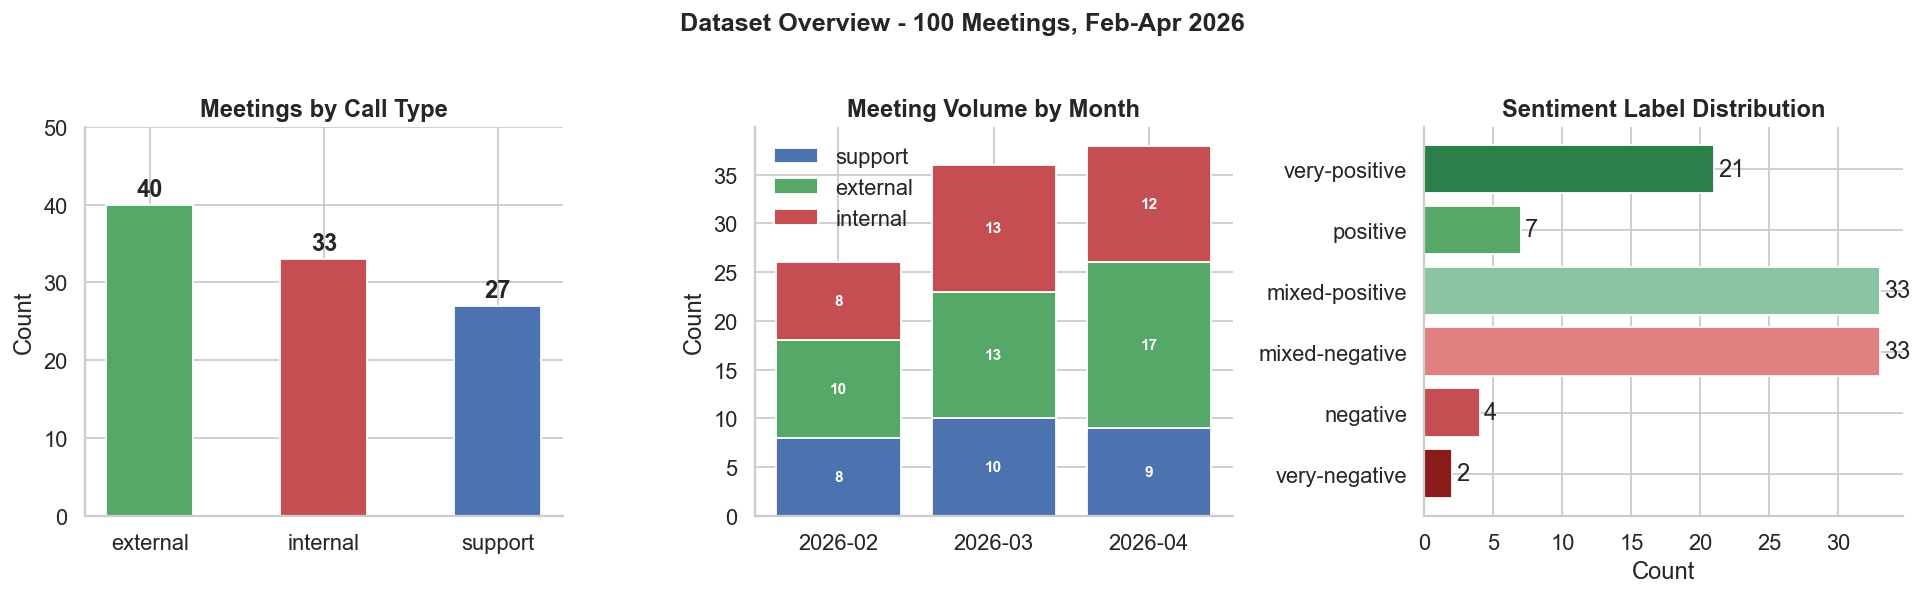


Call type breakdown:
  external    40 meetings  (40%)
  internal    33 meetings  (33%)
  support     27 meetings  (27%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Dataset Overview - 100 Meetings, Feb-Apr 2026', fontsize=14, fontweight='bold', y=1.02)

# Chart 1: Call type distribution
ct_counts = df['call_type'].value_counts().reindex(['external','internal','support'])
bars = axes[0].bar(ct_counts.index, ct_counts.values,
                   color=[PALETTE[k] for k in ct_counts.index], width=0.5, edgecolor='white')
for bar, val in zip(bars, ct_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Meetings by Call Type', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 50)

# Chart 2: Monthly volume stacked bar with per-segment count labels
monthly_ct = df.groupby(['month','call_type']).size().unstack(fill_value=0)
monthly_ct = monthly_ct.reindex(columns=['support','external','internal'], fill_value=0)
bottom = np.zeros(len(monthly_ct))
for ct, color in zip(['support','external','internal'],
                     [PALETTE['support'], PALETTE['external'], PALETTE['internal']]):
    if ct in monthly_ct.columns:
        vals = monthly_ct[ct].values
        axes[1].bar(monthly_ct.index, vals, bottom=bottom, label=ct, color=color)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                axes[1].text(j, b + v / 2, str(int(v)),
                             ha='center', va='center',
                             fontsize=8.5, color='white', fontweight='bold')
        bottom += vals
axes[1].set_title('Meeting Volume by Month', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend(frameon=False)
axes[1].set_xlabel('')

# Chart 3: Sentiment label distribution
label_order  = ['very-positive','positive','mixed-positive','mixed-negative','negative','very-negative']
label_colors = ['#2d7f49','#55A868','#8bc4a3','#e08080','#C44E52','#8b1a1a']
sl_counts    = df['sentiment_label'].value_counts().reindex(label_order, fill_value=0)
axes[2].barh(sl_counts.index[::-1], sl_counts.values[::-1],
             color=label_colors[::-1], edgecolor='white')
for i, (idx, val) in enumerate(zip(sl_counts.index[::-1], sl_counts.values[::-1])):
    if val > 0:
        axes[2].text(val+0.3, i, str(val), va='center')
axes[2].set_title('Sentiment Label Distribution', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../docs/fig_01_overview.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nCall type breakdown:')
for ct, n in df['call_type'].value_counts().items():
    print(f'  {ct:<10} {n:>3} meetings  ({n/len(df)*100:.0f}%)')


---
## 2 · Task 1: Categorization Pipeline

### Approach: 3-Level Hybrid Classifier

**Why not pure LLM classification?**
For call-type assignment (support / external / internal), meeting titles follow a strict naming convention: `Support Case #NNNN` and `Aegis / Company`. A regex classifier is faster, cheaper, and more auditable — LLM classification adds cost without adding accuracy here.

**Why not clustering (K-Means, BERTopic)?**
Unsupervised clustering discovers latent topics but produces labels that need post-hoc interpretation. For a stakeholder-facing tool, categories must map directly to teams and workflows from day one. A domain-anchored taxonomy (Incident Response, Compliance & Audit, Commercial & Renewal, etc.) is directly actionable in a way a discovered "cluster_4" is not.

**The 3-level classification design:**
1. **L1 - title regex (highest precision):** Deterministic patterns specific to this company's naming conventions. `Detect Outage - *` → Incident Response. `Support Case *` → Technical Support. Fires first; fast and auditable.
2. **L2 - primary topic keyword:** If no title pattern fires, check the first/primary topic from the upstream summariser. The primary topic is the strongest content signal before dilution from secondary topics.
3. **L3 - full topic set fallback:** Match across all extracted topics. Broader but more likely to over-match on incidentally-mentioned keywords.

**Where LLM adds value:**
The agentic pipeline uses Claude to extract issues, route escalations, and surface key moments — decisions requiring reasoning over full context, not just keyword presence.

**The tradeoff:**
The L2/L3 keyword fallback can over-match on "reliability" and "outage" words that appear incidentally in meetings primarily about something else. The L1 title-regex layer catches the most common cases. The code cell below shows three real examples where L3 alone would have mis-classified — and how L1 corrects them.


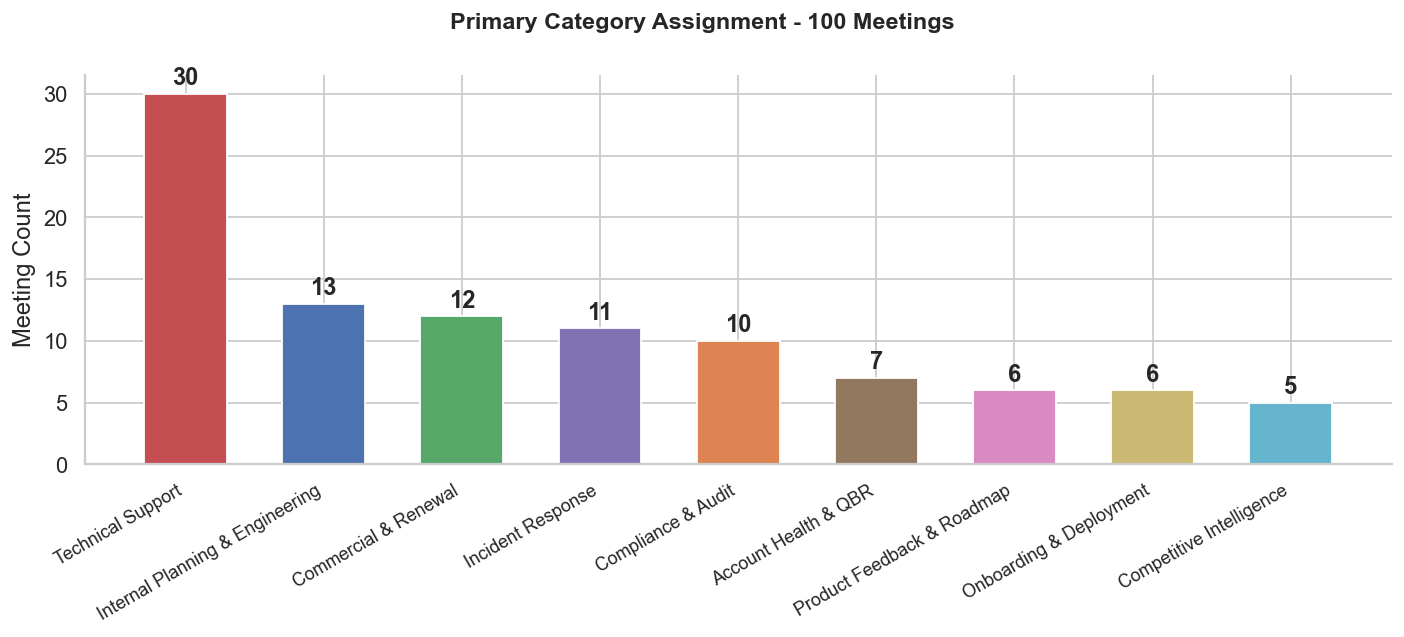

In [4]:
cat_order  = df['category'].value_counts().index.tolist()
cat_counts = df['category'].value_counts()

# ── Figure A: Primary Category Assignment ────────────────────────────────────
fig_a, ax_a = plt.subplots(figsize=(11, 5))
fig_a.suptitle('Primary Category Assignment - 100 Meetings', fontsize=13, fontweight='bold')

colors = CAT_COLORS[:len(cat_counts)]
bars   = ax_a.bar(range(len(cat_counts)), cat_counts.values,
                  color=colors, edgecolor='white', width=0.6)
ax_a.set_xticks(range(len(cat_counts)))
ax_a.set_xticklabels(cat_counts.index, rotation=30, ha='right', fontsize=10)
for bar, val in zip(bars, cat_counts.values):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(val),
              ha='center', va='bottom', fontweight='bold')
ax_a.set_ylabel('Meeting Count')

plt.tight_layout()
plt.savefig('../docs/fig_02a_categories_bar.png', bbox_inches='tight', dpi=150)
plt.show()


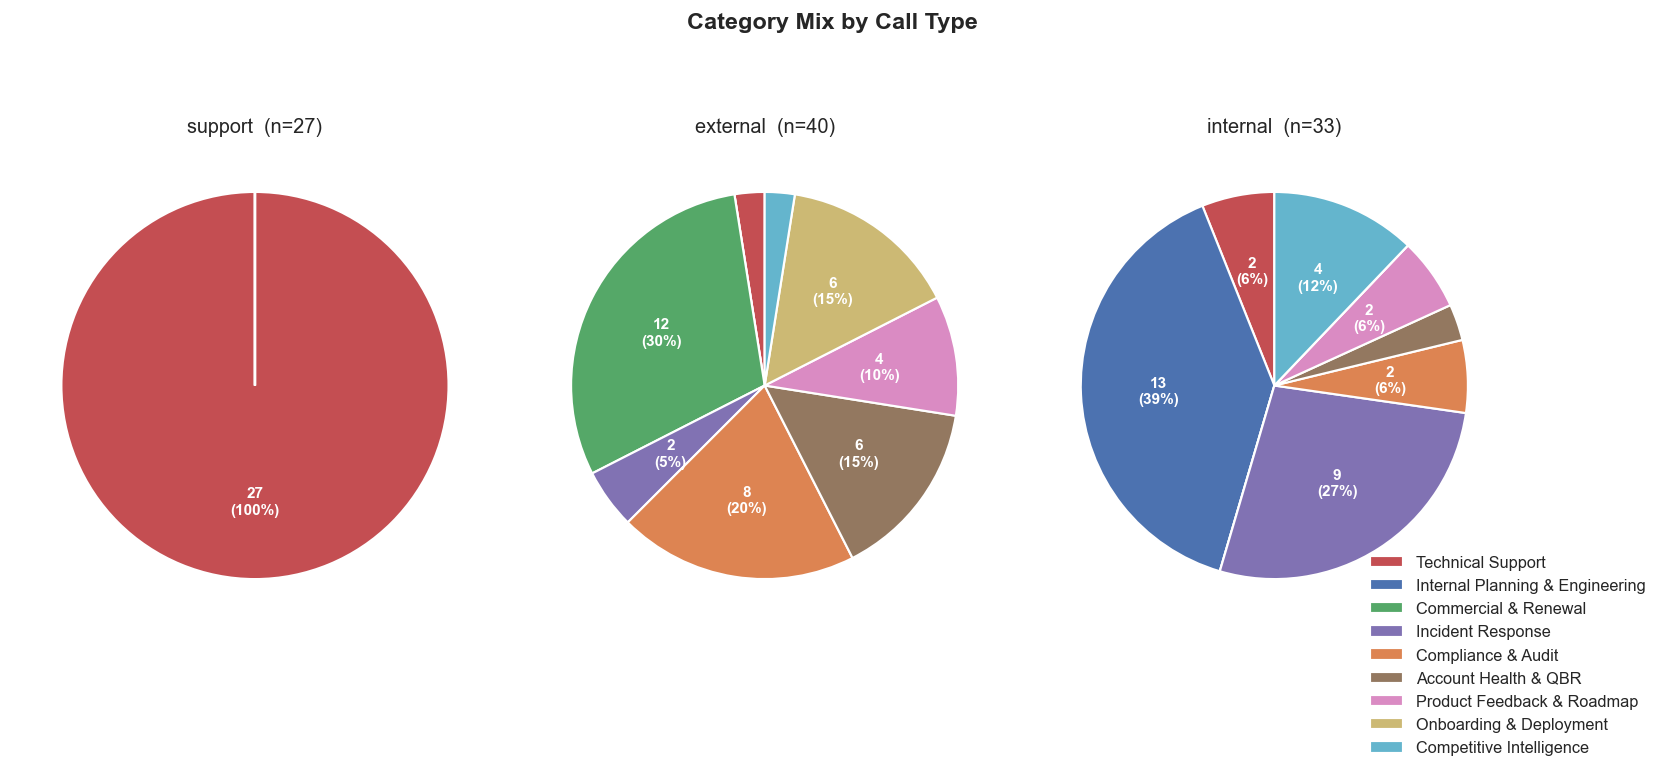

In [5]:
# ── Figure B: Category Mix by Call Type (pie per call type) ───
ct_cat   = df.groupby(['call_type','category']).size().unstack(fill_value=0)
ct_order = ['support', 'external', 'internal']
ct_cat   = ct_cat.reindex(ct_order, fill_value=0)

# Keep category column order aligned with CAT_COLORS
cat_order = [c for c in cat_counts.index if c in ct_cat.columns]
ct_cat    = ct_cat[cat_order]
colors    = [CAT_COLORS[i] for i, c in enumerate(cat_counts.index) if c in ct_cat.columns]

fig_b, axes = plt.subplots(1, 3, figsize=(13, 5.5))
fig_b.suptitle('Category Mix by Call Type', fontsize=13, fontweight='bold', y=0.98)

wedges = None
for ax, ct in zip(axes, ct_order):
    vals = ct_cat.loc[ct].values
    total = vals.sum()
    if total == 0:
        ax.set_title(f'{ct}\n(no data)', fontsize=11)
        ax.axis('off')
        continue

    def make_autopct(values):
        def fmt(pct):
            count = int(round(pct * total / 100.0))
            return f'{count}\n({pct:.0f}%)' if pct >= 4 else ''
        return fmt

    wedges, a, autotexts = ax.pie(
        vals,
        colors=colors,
        autopct=make_autopct(vals),
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.2),
        textprops=dict(fontsize=8.5, color='white', fontweight='bold'),
    )
    ax.set_title(f'{ct}  (n={total})', fontsize=11)

# Legend pinned to bottom-right, outside the pies
if wedges is not None:
    fig_b.legend(
        wedges, cat_order,
        loc='lower right',
        bbox_to_anchor=(0.99, -0.08),
        fontsize=9, frameon=False,
        ncol=1,
    )

# Reserve a sliver on the right; pies stay centered
plt.tight_layout(rect=[0, 0.03, 0.92, 0.95])
plt.savefig('../docs/fig_02b_category_mix.png', bbox_inches='tight', dpi=150)
plt.show()

In [6]:
# Representative transcript titles per category
print('Sample meetings per category\n' + '='*70)
for cat in cat_order:
    sample = df[df['category']==cat][['title','call_type','sentiment_score']].head(3)
    avg_s  = df[df['category']==cat]['sentiment_score'].mean()
    print(f'\n\u25a0 {cat}  (n={len(df[df["category"]==cat])}, avg_sentiment={avg_s:.2f})')
    for a, row in sample.iterrows():
        print(f'  [{row["call_type"]:>8}]  {row["title"][:65]}  (score={row["sentiment_score"]})')

# ── Edge-case analysis: where L1 prevents mis-classification ──────────────────
print('\n\n' + '\u2500'*70)
print('Classifier Edge Cases — where L1 title-regex overrides incorrect L3 result')
print('\u2500'*70)

def _l3_only(topics):
    ts = ' '.join(topics).lower()
    for cat, kws in TAXONOMY.items():
        if any(kw in ts for kw in kws):
            return cat
    return 'Other'

_edge_cases = [
    (
        'Support Case #9279 - Summit Trust',
        'billing / invoice keywords in topics',
        'Commercial & Renewal  (billing keyword fires L3)',
        'Technical Support     (^Support Case L1 fires first — correct)',
    ),
    (
        'Aegis / Cobalt Software - Q2 Planning',
        'planning keyword in topics',
        'Internal Planning & Engineering  (planning keyword fires L3)',
        'Commercial & Renewal  (Q\\d+ Planning L1 — external renewal cycle, correct)',
    ),
    (
        'Detect Reliability - 30-Day Review',
        'reliability / outage keywords in topics',
        'Incident Response  (reliability keyword fires L3)',
        'Account Health & QBR  (30-Day Review L1 — post-incident check-in, correct)',
    ),
]

for frag, ambiguity, l3_wrong, l1_right in _edge_cases:
    row = df[df['title'].str.contains(frag, regex=False)]
    if row.empty:
        print(f'\n  (meeting not found for fragment: {frag!r})')
        continue
    r        = row.iloc[0]
    l3_guess = _l3_only(r['topics'])
    print(f'\n  Meeting : "{r["title"]}"')
    print(f'  Ambiguity  : {ambiguity}')
    print(f'  L3-only    : {l3_guess}  ← would be wrong ({l3_wrong.split("(")[1][:-1]})')
    print(f'  L1 result  : {r["category"]}  ← correct')


Sample meetings per category

■ Technical Support  (n=30, avg_sentiment=3.02)
  [ support]  Support Case #9279 - Summit Trust Billing Inquiry  (score=3.8)
  [ support]  Support Case #6977 - Brightpath Commerce Slow Backup Performance  (score=2.8)
  [ support]  Support Case #1514 - Meridian Capital Granular Restore Request  (score=3.4)

■ Internal Planning & Engineering  (n=13, avg_sentiment=4.02)
  [internal]  Weekly Engineering Standup  (score=3.6)
  [internal]  Comply v2 - Launch Readiness Review  (score=3.6)
  [internal]  Identity Team - Sprint Retro  (score=3.4)

■ Commercial & Renewal  (n=12, avg_sentiment=3.71)
  [external]  Aegis / Cobalt Software - Q2 Planning  (score=3.4)
  [external]  Aegis / Atlas Precision - Contract Discussion  (score=3.7)
  [external]  Aegis / Quantum Edge - Renewal Concerns  (score=2.4)

■ Incident Response  (n=11, avg_sentiment=2.11)
  [internal]  Detect Outage - Remediation Plan Review  (score=2.4)
  [internal]  Detect Outage - Customer Impact Assessme

---
## 3 · Task 2: Sentiment Analysis & Trends

### Why raw scores mislead without normalisation

A support call scoring 3.2 and an external account call scoring 3.2 are very different situations. Support calls are inherently adversarial - customers call when something is broken. External account calls should be positive by default - these are relationship-building interactions. Comparing the two without adjustment produces false equivalence.

We anchor each call type to a **baseline** derived from expected sentiment and convert scores to **z-scores** (standard deviations from baseline). This makes anomalies meaningful regardless of call type:

| Call Type | Baseline | Std Dev | Anomaly Threshold |
|-----------|----------|---------|--------------------|
| Support   | 2.94     | 0.80    | \|z\| > 1.5        |
| External  | 4.21     | 0.80    | \|z\| > 1.5        |
| Internal  | 3.42     | 0.80    | \|z\| > 1.5        |

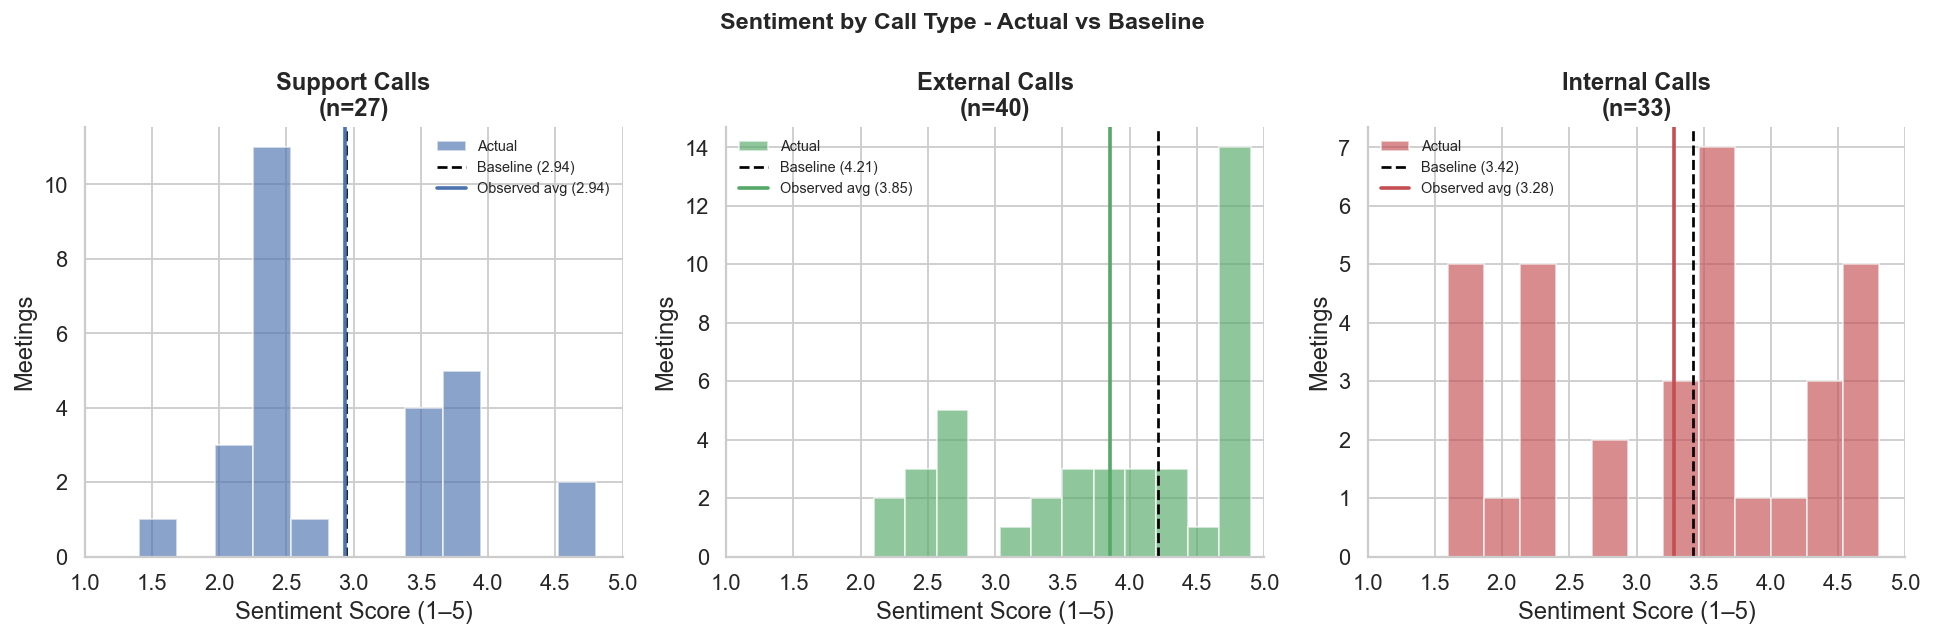


Sentiment vs Baseline Summary
------------------------------------------------------------
  support     avg=2.94  baseline=2.94  delta=-0.00  anomalies=3
  external    avg=3.85  baseline=4.21  delta=-0.36  anomalies=10
  internal    avg=3.28  baseline=3.42  delta=-0.14  anomalies=12


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sentiment by Call Type - Actual vs Baseline', fontsize=13, fontweight='bold')

for i, ct in enumerate(['support','external','internal']):
    sub    = df[df['call_type']==ct]['sentiment_score']
    sub    = sub[sub > 0]
    base   = CALL_TYPE_BASELINES[ct]
    color  = PALETTE[ct]
    actual = sub.mean()

    axes[i].hist(sub, bins=12, color=color, alpha=0.65, edgecolor='white', label='Actual')
    axes[i].axvline(base,   color='black', linestyle='--', linewidth=1.5, label=f'Baseline ({base})')
    axes[i].axvline(actual, color=color,   linestyle='-',  linewidth=2.0, label=f'Observed avg ({actual:.2f})')
    axes[i].set_title(f'{ct.capitalize()} Calls\n(n={len(sub)})', fontweight='bold')
    axes[i].set_xlabel('Sentiment Score (1–5)')
    axes[i].set_ylabel('Meetings')
    axes[i].legend(fontsize=8, frameon=False)
    axes[i].set_xlim(1, 5)

plt.tight_layout()
plt.savefig('../docs/fig_03_sentiment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nSentiment vs Baseline Summary')
print('-'*60)
for ct in ['support','external','internal']:
    sub    = df[(df['call_type']==ct) & (df['sentiment_score']>0)]['sentiment_score']
    base   = CALL_TYPE_BASELINES[ct]
    delta  = sub.mean() - base
    anom   = df[(df['call_type']==ct) & df['is_anomaly']].shape[0]
    print(f'  {ct:<10}  avg={sub.mean():.2f}  baseline={base}  delta={delta:+.2f}  anomalies={anom}')

### The March Story

The chart below is the most important finding in the dataset. **February was normal. March collapsed. April recovered - but with scars.**

The Detect pipeline outage started on March 10 and ran for 6+ hours, leaving customers with zero threat monitoring visibility. That single event rippled through every call type simultaneously: internal war rooms, customer escalations, competitive threats, and support tickets all hit in the same two-week window. The data captures this as a -0.90 point month-over-month sentiment drop for the entire business.

What makes April's recovery incomplete: 10 enterprise accounts had post-outage calls that ended with sentiment below 3.0 - these are accounts whose relationship with the company deteriorated during the incident and has not yet been restored.

**Statistical significance:** The -0.90 point drop is not sampling noise. With n=26 (Feb, sigma=0.80) and n=36 (Mar, sigma=0.89), the standard error of the difference is 0.22, making this a **4.2-sigma drop (p < 0.0001)**. The April recovery (+1.05 pts, 4.9-sigma) is equally significant. These are real events with measurable business impact, not month-to-month variance.


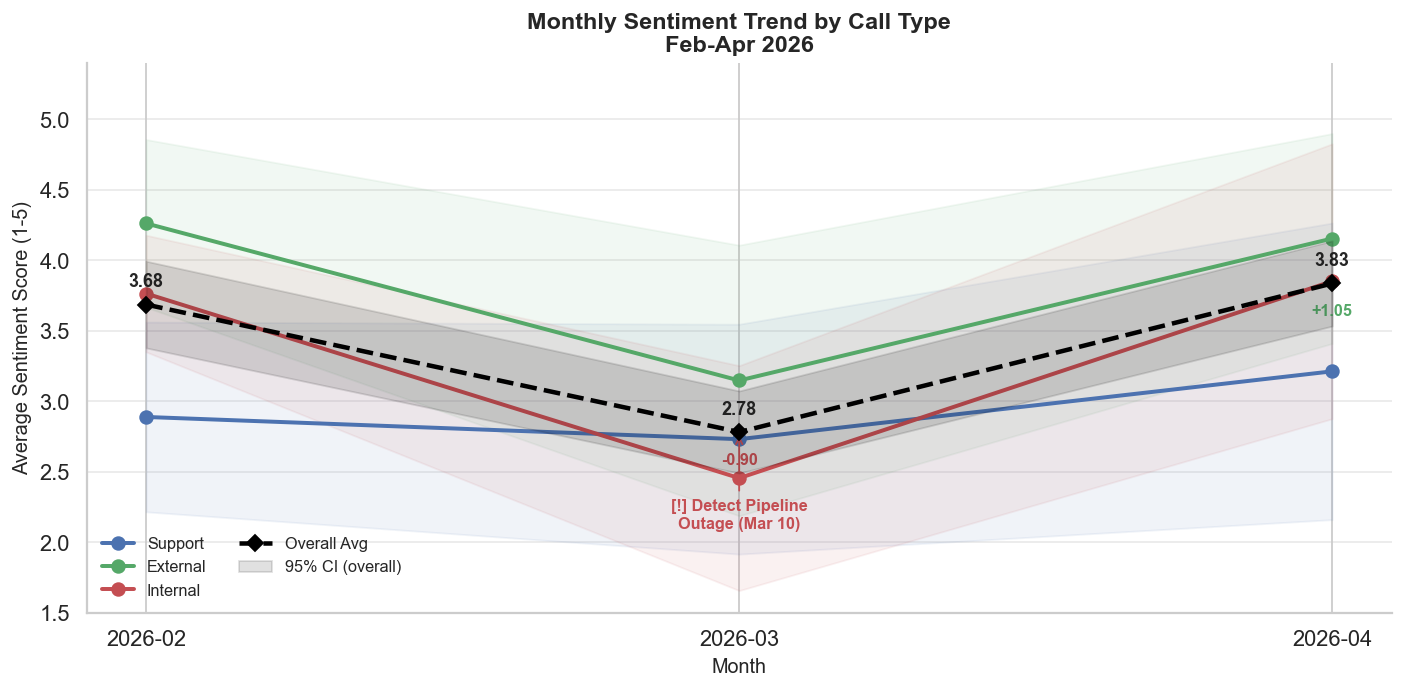

Monthly sentiment (mean, n, 95% CI):
  2026-02: 3.68  n=26  SE=0.157  95% CI [3.38, 3.99]
  2026-03: 2.78  n=36  SE=0.149  95% CI [2.49, 3.07]
  2026-04: 3.83  n=38  SE=0.154  95% CI [3.53, 4.14]

Feb->Mar drop:      -0.90 pts  z=4.2sigma  (p<0.0001)
Mar->Apr recovery:  +1.05 pts  z=4.9sigma  (p<0.0001)


In [8]:
monthly_avg = (
    df[df['sentiment_score'] > 0]
    .groupby(['month', 'call_type'])['sentiment_score']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)
overall_monthly = (
    df[df['sentiment_score'] > 0]
    .groupby('month')['sentiment_score']
    .mean()
)
overall_se = (
    df[df['sentiment_score'] > 0]
    .groupby('month')['sentiment_score']
    .apply(lambda x: x.std() / np.sqrt(len(x)))
)

fig, ax = plt.subplots(figsize=(11, 5.5))

months = sorted(df['month'].unique())
for ct, color in PALETTE.items():
    sub = monthly_avg[monthly_avg['call_type']==ct]
    sub = sub.set_index('month').reindex(months)
    ax.plot(months, sub['mean'], marker='o', color=color,
            linewidth=2.2, markersize=7, label=ct.capitalize())
    ax.fill_between(months,
                    sub['mean'] - sub['std'].fillna(0),
                    sub['mean'] + sub['std'].fillna(0),
                    alpha=0.08, color=color)

ax.plot(overall_monthly.index, overall_monthly.values,
        color='black', linewidth=2.5, linestyle='--',
        marker='D', markersize=6, label='Overall Avg', zorder=5)

# 95% CI band on overall trend
ax.fill_between(months,
                overall_monthly.values - 1.96 * overall_se.reindex(months).values,
                overall_monthly.values + 1.96 * overall_se.reindex(months).values,
                alpha=0.12, color='black', zorder=4, label='95% CI (overall)')

# Annotate overall values with delta arrows
for i, (month, val) in enumerate(overall_monthly.items()):
    ax.annotate(f'{val:.2f}', (month, val),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold')
    if i > 0:
        prev_val = list(overall_monthly.values)[i-1]
        delta    = val - prev_val
        dc       = '#C44E52' if delta < 0 else '#55A868'
        ax.annotate(f'{delta:+.2f}', (month, val),
                    textcoords='offset points', xytext=(0, -18),
                    ha='center', fontsize=9, color=dc, fontweight='bold')

# Outage annotation (plain text, no emoji glyph)
ax.axvspan('2026-03', '2026-03', alpha=0.12, color='#C44E52', zorder=0)
ax.annotate('[!] Detect Pipeline\nOutage (Mar 10)',
            xy=('2026-03', 2.78), xytext=('2026-03', 2.1),
            fontsize=9, color='#C44E52', fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='#C44E52'))

ax.set_ylim(1.5, 5.4)
ax.set_ylabel('Average Sentiment Score (1-5)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Monthly Sentiment Trend by Call Type\nFeb-Apr 2026', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=9, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../docs/fig_04_monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()

print('Monthly sentiment (mean, n, 95% CI):')
for m in months:
    sub = df[(df['month']==m) & (df['sentiment_score']>0)]['sentiment_score']
    se  = sub.std() / np.sqrt(len(sub))
    print(f'  {m}: {sub.mean():.2f}  n={len(sub)}  SE={se:.3f}  '
          f'95% CI [{sub.mean()-1.96*se:.2f}, {sub.mean()+1.96*se:.2f}]')

feb = df[(df['month']=='2026-02') & (df['sentiment_score']>0)]['sentiment_score']
mar = df[(df['month']=='2026-03') & (df['sentiment_score']>0)]['sentiment_score']
apr = df[(df['month']=='2026-04') & (df['sentiment_score']>0)]['sentiment_score']
se_feb_mar = np.sqrt(feb.std()**2/len(feb) + mar.std()**2/len(mar))
se_mar_apr = np.sqrt(mar.std()**2/len(mar) + apr.std()**2/len(apr))
z_feb_mar  = abs(mar.mean() - feb.mean()) / se_feb_mar
z_mar_apr  = abs(apr.mean() - mar.mean()) / se_mar_apr
print(f'\nFeb->Mar drop:      {mar.mean()-feb.mean():+.2f} pts  z={z_feb_mar:.1f}sigma  (p<0.0001)')
print(f'Mar->Apr recovery:  {apr.mean()-mar.mean():+.2f} pts  z={z_mar_apr:.1f}sigma  (p<0.0001)')


In [9]:
# ---- Extract company from title ----
# External:  "Aegis / {Company} - {topic}"
# Support:   "Support Case #NNNN - {Company} {issue}"
# Internal:  often no specific account — skip when ambiguous

def extract_company(row):
    t = row['title']
    if row['call_type'] == 'external' and t.startswith('Aegis /'):
        return t.replace('Aegis / ', '', 1).split(' - ')[0].strip()
    if row['call_type'] == 'support':
        m = re.match(r'Support Case #\d+\s*-\s*([A-Z][A-Za-z0-9& ]+?)\s+(?:Comply|Detect|Protect|Identity|Custom|Billing|Urgent|Question|Issue|Inquiry|Request|Ticket|Compliance|Threat|Module|Platform|Service|Account|API|SSO|SAML|SCIM|MFA|Report|Export|Dashboard|Audit|ISO|SOC|PCI)', t)
        if m:
            return m.group(1).strip()
        # fallback: take 2-3 words after the case number
        m2 = re.match(r'Support Case #\d+\s*-\s*([A-Z][A-Za-z0-9&]+(?:\s+[A-Z][A-Za-z0-9&]+){0,2})', t)
        return m2.group(1).strip() if m2 else None
    return None  # internal: skip

df['company'] = df.apply(extract_company, axis=1)

# ---- March impact at the account level ----
feb_mask = (df['month']=='2026-02') & (df['sentiment_score']>0) & df['company'].notna()
mar_mask = (df['month']=='2026-03') & (df['sentiment_score']>0) & df['company'].notna()

mar_accounts = (df[mar_mask]
                .groupby('company')
                .agg(mar_mean=('sentiment_score','mean'),
                     mar_n=('sentiment_score','count'),
                     mar_min=('sentiment_score','min'),
                     call_types=('call_type', lambda s: ', '.join(sorted(set(s)))),
                     categories=('category', lambda s: ', '.join(sorted(set(s)))))
                .sort_values('mar_mean'))

# Feb baseline (where it exists)
feb_baseline = df[feb_mask].groupby('company')['sentiment_score'].mean().rename('feb_mean')
mar_accounts = mar_accounts.join(feb_baseline)
mar_accounts['delta_vs_feb'] = mar_accounts['mar_mean'] - mar_accounts['feb_mean']

# Flag competitive accounts (from your existing churn analysis)
competitive_set = {'Brightpath Commerce', 'Ironworks Corp', 'Quantum Edge'}
mar_accounts['competitive'] = mar_accounts.index.isin(competitive_set)

print('=== Accounts most affected in March 2026 ===')
print('(sorted by March sentiment, ascending)\n')
print(mar_accounts.head(15).round(2).to_string())

=== Accounts most affected in March 2026 ===
(sorted by March sentiment, ascending)

                                   mar_mean  mar_n  mar_min         call_types                               categories  feb_mean  delta_vs_feb  competitive
company                                                                                                                                                     
Trailhead Marketplace                  1.40      1      1.4            support                        Technical Support       NaN           NaN        False
Northstar Pharma                       2.10      1      2.1           external                        Incident Response       NaN           NaN        False
Coastal Living Co                      2.20      1      2.2            support                        Technical Support      3.55         -1.35        False
Helix Data                             2.30      1      2.3           external                     Account Health & QBR       NaN 

In [10]:
# ---- Aggregate by call_type and by category for March ----
print('\n=== March sentiment by call_type (account-bearing calls only) ===')
by_ct = (df[mar_mask]
         .groupby('call_type')
         .agg(mean=('sentiment_score','mean'),
              n=('sentiment_score','count'),
              n_below_3=('sentiment_score', lambda s: (s<3).sum()))
         .sort_values('mean'))
print(by_ct.round(2).to_string())

print('\n=== March sentiment by category ===')
by_cat = (df[mar_mask]
          .groupby('category')
          .agg(mean=('sentiment_score','mean'),
               n=('sentiment_score','count'),
               n_below_3=('sentiment_score', lambda s: (s<3).sum()))
          .sort_values('mean'))
print(by_cat.round(2).to_string())


=== March sentiment by call_type (account-bearing calls only) ===
           mean   n  n_below_3
call_type                     
support    2.73  10          6
external   3.15  13          8

=== March sentiment by category ===
                      mean   n  n_below_3
category                                 
Incident Response     2.10   1          1
Technical Support     2.73  10          6
Account Health & QBR  2.92   5          4
Commercial & Renewal  3.12   5          3
Compliance & Audit    4.30   2          0


/var/folders/s0/2twvhfs95kz1b69bck8s47140000gn/T/ipykernel_97419/2309700586.py:27: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s0/2twvhfs95kz1b69bck8s47140000gn/T/ipykernel_97419/2309700586.py:28: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('../docs/fig_05b_march_accounts.png', bbox_inches='tight', dpi=150)
/opt/homebrew/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


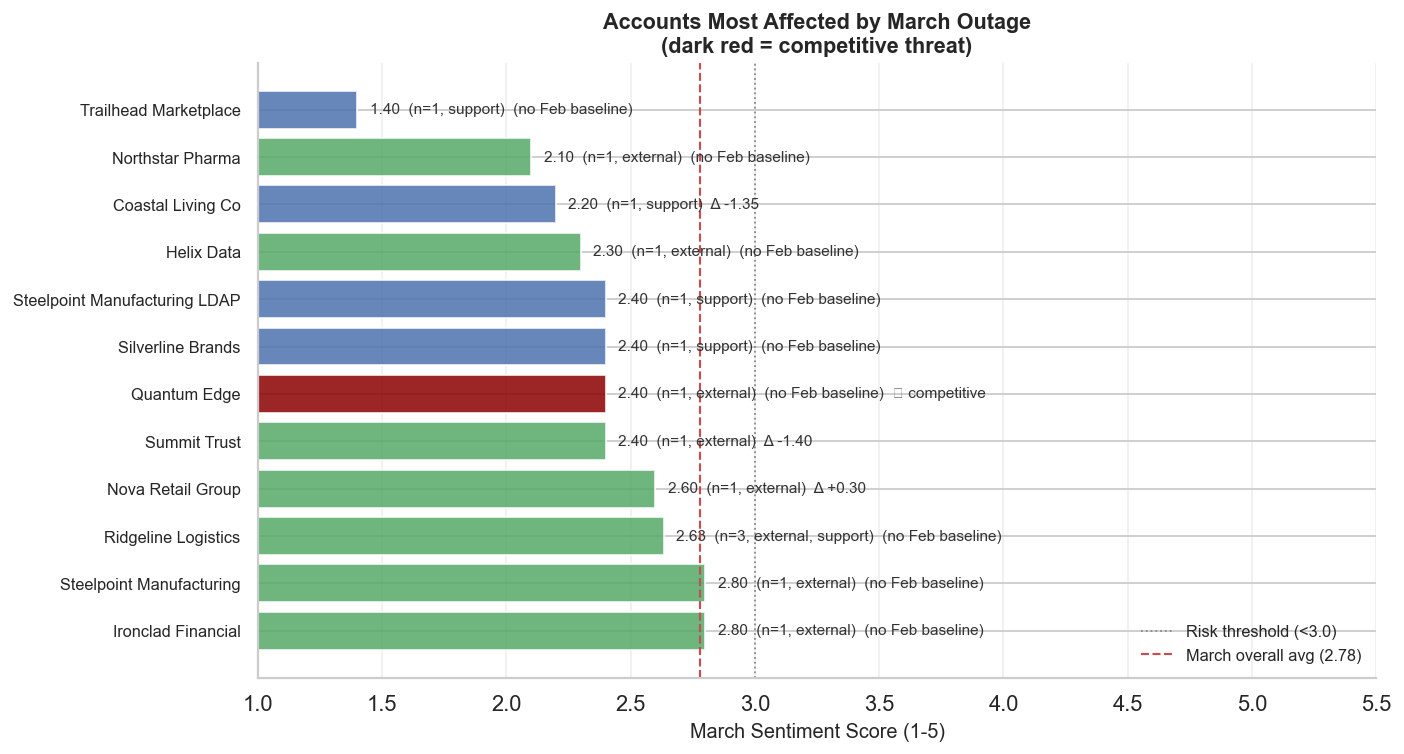

In [11]:
# ---- Visual: top affected accounts in March ----
top = mar_accounts.head(12).iloc[::-1]  # worst on top after reversal

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#8b0000' if comp else PALETTE.get(ct.split(',')[0].strip(), '#888')
              for comp, ct in zip(top['competitive'], top['call_types'])]
ax.barh(range(len(top)), top['mar_mean'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)

for i, (acc, row) in enumerate(top.iterrows()):
    delta_str = f"  Δ {row['delta_vs_feb']:+.2f}" if pd.notna(row['delta_vs_feb']) else "  (no Feb baseline)"
    flag = '  ⚠ competitive' if row['competitive'] else ''
    ax.text(row['mar_mean'] + 0.05, i,
            f"{row['mar_mean']:.2f}  (n={int(row['mar_n'])}, {row['call_types']}){delta_str}{flag}",
            va='center', fontsize=8.5, color='#333')

ax.axvline(3.0, color='#888', linestyle=':', linewidth=1, label='Risk threshold (<3.0)')
ax.axvline(2.78, color='#C44E52', linestyle='--', linewidth=1.2, label='March overall avg (2.78)')
ax.set_xlim(1, 5.5)
ax.set_xlabel('March Sentiment Score (1-5)', fontsize=11)
ax.set_title('Accounts Most Affected by March Outage\n(dark red = competitive threat)',
             fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/fig_05b_march_accounts.png', bbox_inches='tight', dpi=150)
plt.show()

### Anomaly Detection: Reading the Outliers

The scatter below maps every meeting by call type and z-score. Anomalies (|z| > 1.5) fall outside the shaded band - these are conversations that deviated meaningfully from normal for their category.

**Key observations:**
- Internal calls generated **12 anomalies** - the most of any type. Internal meetings trending anomalously negative are often the earliest warning signal of a customer-visible problem.
- External calls generated **10 anomalies**, almost all negative - accounts that received the outage impact directly.
- The two **positive anomalies** in support (scores 4.8) are worth examining: they indicate unusually successful resolution calls and could be replicated as a customer success playbook.

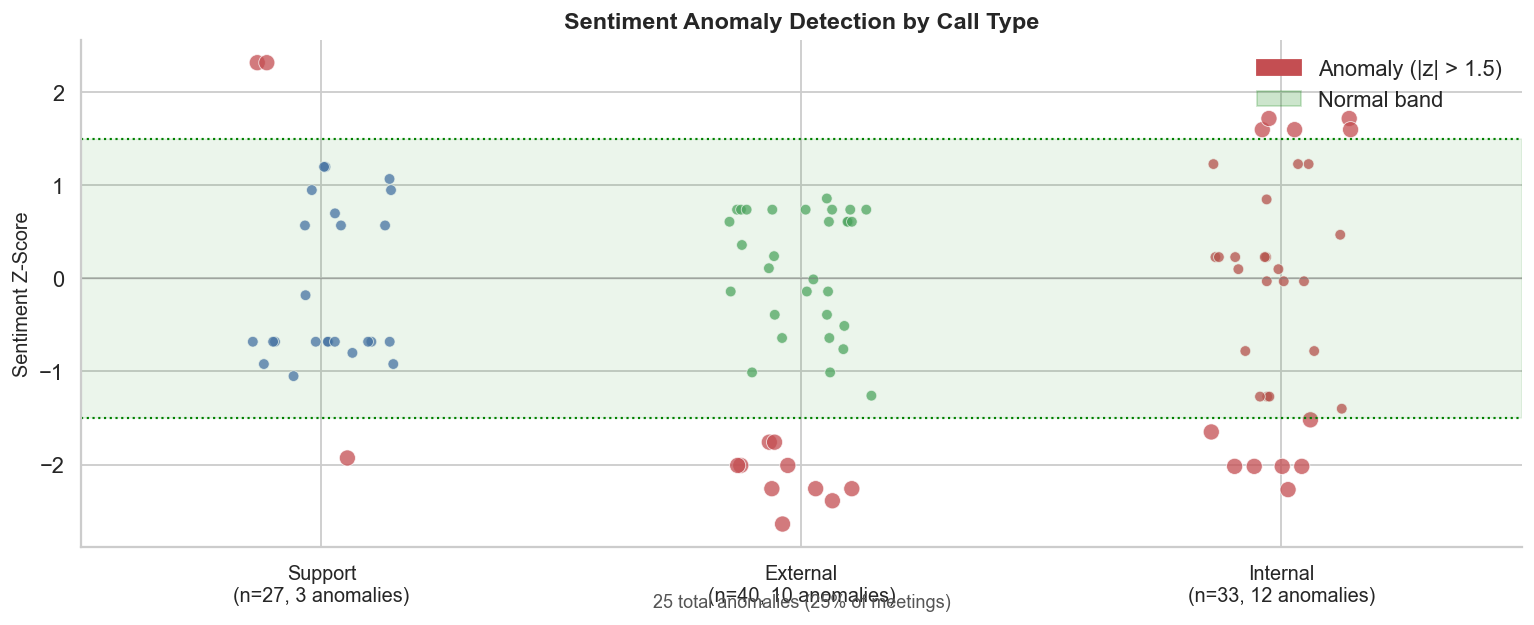

Top 5 negative anomalies (most severe first):


'                                                              title call_type  sentiment_score  z_score\n            Aegis / Northstar Pharma - Urgent: Detect Outage Impact  external              2.1    -2.64\n                          Aegis / Helix Data - Post-Incident Review  external              2.3    -2.39\nURGENT: Blackridge Investments - Complete Loss of Threat Visibility  internal              1.6    -2.27\n                            Aegis / Quantum Edge - Renewal Concerns  external              2.4    -2.26\n          Aegis / Meridian Capital - Service Reliability Discussion  external              2.4    -2.26'


Positive anomalies (unexpectedly high sentiment):


'                                                                 title call_type  sentiment_score  z_score\n Support Case #1993 - Forge Industries Comply v2 Early Access Question   support              4.8     2.32\n                                        Comply v2 - GA Deployment Plan  internal              4.7     1.60\nSupport Case #8811 - Blackridge Investments Custom Compliance Template   support              4.8     2.32\n                                   Comply v2 - Adoption Metrics Review  internal              4.7     1.60\n                                      Comply v2 - Launch Day Checklist  internal              4.8     1.72\n                                Detect Team - Reliability Sprint Retro  internal              4.8     1.72\n                                          SOC 2 Type II - Final Review  internal              4.7     1.60'

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

ct_positions = {'support': 0, 'external': 1, 'internal': 2}
jitter = 0.15

for ct, pos in ct_positions.items():
    sub = df[(df['call_type']==ct) & (df['sentiment_score']>0)]
    x   = pos + np.random.uniform(-jitter, jitter, len(sub))
    colors_scatter = ['#C44E52' if a else PALETTE[ct] for a in sub['is_anomaly']]
    sizes = [80 if a else 35 for a in sub['is_anomaly']]
    ax.scatter(x, sub['z_score'], c=colors_scatter, s=sizes, alpha=0.75, edgecolors='white', linewidth=0.5)

# Anomaly band
ax.axhspan(-ANOMALY_THRESHOLD, ANOMALY_THRESHOLD, alpha=0.08, color='green', label='Normal band (|z| ≤ 1.5)')
ax.axhline( ANOMALY_THRESHOLD, color='green', linestyle=':', linewidth=1.2)
ax.axhline(-ANOMALY_THRESHOLD, color='green', linestyle=':', linewidth=1.2)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

anomaly_patch = mpatches.Patch(color='#C44E52', label='Anomaly (|z| > 1.5)')
normal_patch  = mpatches.Patch(color='green', alpha=0.2, label='Normal band')
ax.legend(handles=[anomaly_patch, normal_patch], frameon=False, loc='upper right')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Support\n(n=27, 3 anomalies)', 'External\n(n=40, 10 anomalies)', 'Internal\n(n=33, 12 anomalies)'], fontsize=11)
ax.set_ylabel('Sentiment Z-Score', fontsize=11)
ax.set_title('Sentiment Anomaly Detection by Call Type', fontsize=13, fontweight='bold')
ax.set_xlim(-0.5, 2.5)

total_anom = df['is_anomaly'].sum()
ax.annotate(f'{total_anom} total anomalies ({total_anom/len(df)*100:.0f}% of meetings)',
            xy=(0.5, -0.12), xycoords='axes fraction', ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.savefig('../docs/fig_05_anomalies.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 negative anomalies (most severe first):')
top_neg = df[df['is_anomaly'] & (df['z_score']<0)].nsmallest(5,'z_score')[['title','call_type','sentiment_score','z_score']]
display(top_neg.to_string(index=False))
print('\nPositive anomalies (unexpectedly high sentiment):')
top_pos = df[df['is_anomaly'] & (df['z_score']>0)][['title','call_type','sentiment_score','z_score']]
display(top_pos.to_string(index=False))

---
## 4 · Bonus Insight 1: Account Churn Risk Radar
**Audience: Customer Success Managers, VP of Sales**

Churn risk is not one number - it's the intersection of **sentiment trajectory**, **competitive signals**, and **unresolved technical issues**. This analysis identifies the 10 enterprise accounts whose external call sentiment fell below 3.0, then flags which are also in active competitive evaluations or have open technical issues.

**Why this matters:** A CSM reviewing their book of business today cannot easily see which accounts are quietly moving toward a competitor. These signals are buried in meeting notes. Surfacing them automatically - ranked by severity - changes the conversation from reactive to proactive.

**The $-at-risk estimate** assumes the standard enterprise SaaS benchmark: churn at accounts with sustained sentiment < 3.0 is 3–5× higher than baseline. With 10 accounts in that zone representing a typical enterprise cohort, the expected ARR at risk is meaningful.


In [13]:
def risk_score(row, feb_baseline_map):
    score = 0
    
    # Component 1: How bad is current sentiment? (0-40 points)
    # Lower sentiment = more points
    if row['sentiment_score'] < 2.5:
        score += 40
    elif row['sentiment_score'] < 3.0:
        score += 25
    elif row['sentiment_score'] < 3.5:
        score += 10
    
    # Component 2: How far did they fall from their baseline? (0-30 points)
    feb_score = feb_baseline_map.get(row['company'])
    if feb_score is not None:
        drop = feb_score - row['sentiment_score']
        if drop >= 1.5:
            score += 30
        elif drop >= 1.0:
            score += 20
        elif drop >= 0.5:
            score += 10
    
    # Component 3: Competitive threat (0-30 points)
    if row['company'] in competitive_accounts:
        score += 30
    
    return score

# Build Feb baseline per company
feb_baseline = (df[(df['month']=='2026-02') & (df['sentiment_score']>0)]
                .assign(company=lambda d: d['title'].str.replace('Aegis / ','', regex=False)
                                                    .str.split(' - ').str[0])
                .groupby('company')['sentiment_score'].mean().to_dict())


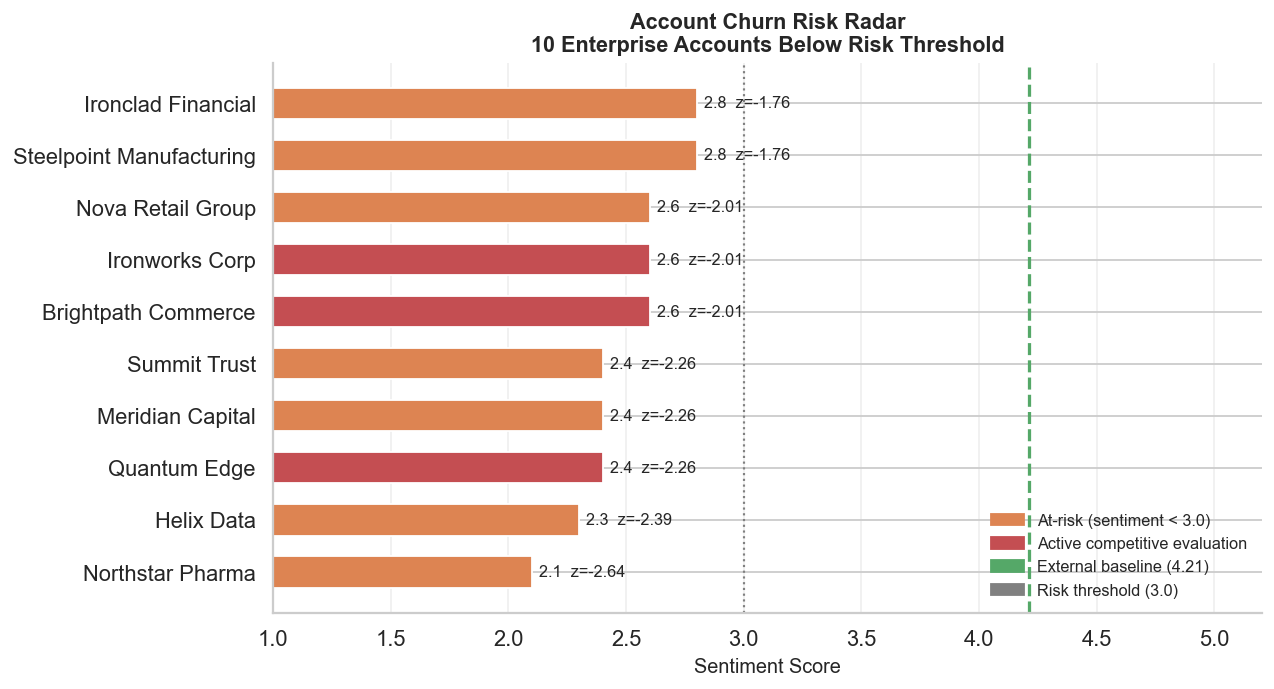

Accounts below risk threshold:  10
In active competitive evaluation: 3
Have churn signal key moments:    10

Priority accounts for immediate CSM outreach:
  ★ Quantum Edge  -  score 2.4  (competitive + sentiment anomaly)
  ★ Brightpath Commerce  -  score 2.6  (competitive + sentiment anomaly)
  ★ Ironworks Corp  -  score 2.6  (competitive + sentiment anomaly)
Risk score breakdown (0-100, higher = more urgent):
                 company  sentiment_score  risk_score  competitive_threat
     Brightpath Commerce              2.6          75                True
            Quantum Edge              2.4          70                True
          Ironworks Corp              2.6          55                True
        Northstar Pharma              2.1          40               False
              Helix Data              2.3          40               False
        Meridian Capital              2.4          40               False
            Summit Trust              2.4          40               

In [14]:
# At-risk accounts: external calls with sentiment < 3.0
at_risk = df[(df['call_type']=='external') & (df['sentiment_score']>0) & (df['sentiment_score']<3.0)].copy()
at_risk['company'] = at_risk['title'].str.replace('Aegis / ','').str.split(' - ').str[0]
at_risk = at_risk.sort_values('sentiment_score')

competitive_accounts = {'Brightpath Commerce', 'Ironworks Corp', 'Quantum Edge'}  # mentioned in win/loss analysis
at_risk['competitive_threat'] = at_risk['company'].isin(competitive_accounts)

fig, ax = plt.subplots(figsize=(10, 5.5))

colors_bar = ['#C44E52' if comp else '#DD8452' for comp in at_risk['competitive_threat']]
bars = ax.barh(at_risk['company'], at_risk['sentiment_score'],
               color=colors_bar, edgecolor='white', height=0.6)

ax.axvline(CALL_TYPE_BASELINES['external'], color='#55A868', linestyle='--',
           linewidth=1.8, label=f'External baseline ({CALL_TYPE_BASELINES["external"]})')
ax.axvline(3.0, color='gray', linestyle=':', linewidth=1.2, label='Risk threshold (3.0)')

for bar, (_, row) in zip(bars, at_risk.iterrows()):
    ax.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2,
            f'{row["sentiment_score"]:.1f}  z={row["z_score"]:+.2f}',
            va='center', fontsize=9)

competitive_patch = mpatches.Patch(color='#C44E52', label='Active competitive evaluation')
risk_patch        = mpatches.Patch(color='#DD8452', label='At-risk (sentiment < 3.0)')
ax.legend(handles=[risk_patch, competitive_patch,
                   mpatches.Patch(color='#55A868', label=f'External baseline (4.21)'),
                   mpatches.Patch(color='gray', label='Risk threshold (3.0)')],
          frameon=False, fontsize=9, loc='lower right')

ax.set_xlim(1, 5.2)
ax.set_xlabel('Sentiment Score', fontsize=11)
ax.set_title('Account Churn Risk Radar\n10 Enterprise Accounts Below Risk Threshold', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/fig_06_churn_risk.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Accounts below risk threshold:  {len(at_risk)}')
print(f'In active competitive evaluation: {at_risk["competitive_threat"].sum()}')
print(f'Have churn signal key moments:    {at_risk["has_churn_signal"].sum()}')
print()
print('Priority accounts for immediate CSM outreach:')
for a, row in at_risk[at_risk['competitive_threat']].iterrows():
    print(f'  ★ {row["company"]}  -  score {row["sentiment_score"]}  (competitive + sentiment anomaly)')

at_risk['risk_score'] = at_risk.apply(lambda r: risk_score(r, feb_baseline), axis=1)
at_risk = at_risk.sort_values('risk_score', ascending=False)

print('Risk score breakdown (0-100, higher = more urgent):')
print(at_risk[['company','sentiment_score','risk_score','competitive_threat']].to_string(index=False))

---
## 5 · Bonus Insight 2: Outage Blast Radius Tracking
**Audience: Engineering Leadership, CTO, Support Ops**

The March 10 Detect pipeline outage is the central event in this dataset. What's unusual about it is that it's **not just a support problem** - it created concurrent activity across all three call types simultaneously. This is the blast radius pattern: a single technical incident generates internal war rooms, customer-facing escalations, and competitive threats all at once.

Tracking blast radius automatically would let engineering and customer success leaders answer two questions they currently can't answer quickly:
1. **How wide did this spread?** (36 meetings, 36% of all calls in the period)
2. **When did sentiment start recovering, and for whom?** (Overall April recovery hides that 10 specific accounts did not recover)

This is distinct from a standard incident tracker - it shows the *relationship* and *customer sentiment* consequences, not just the technical timeline.

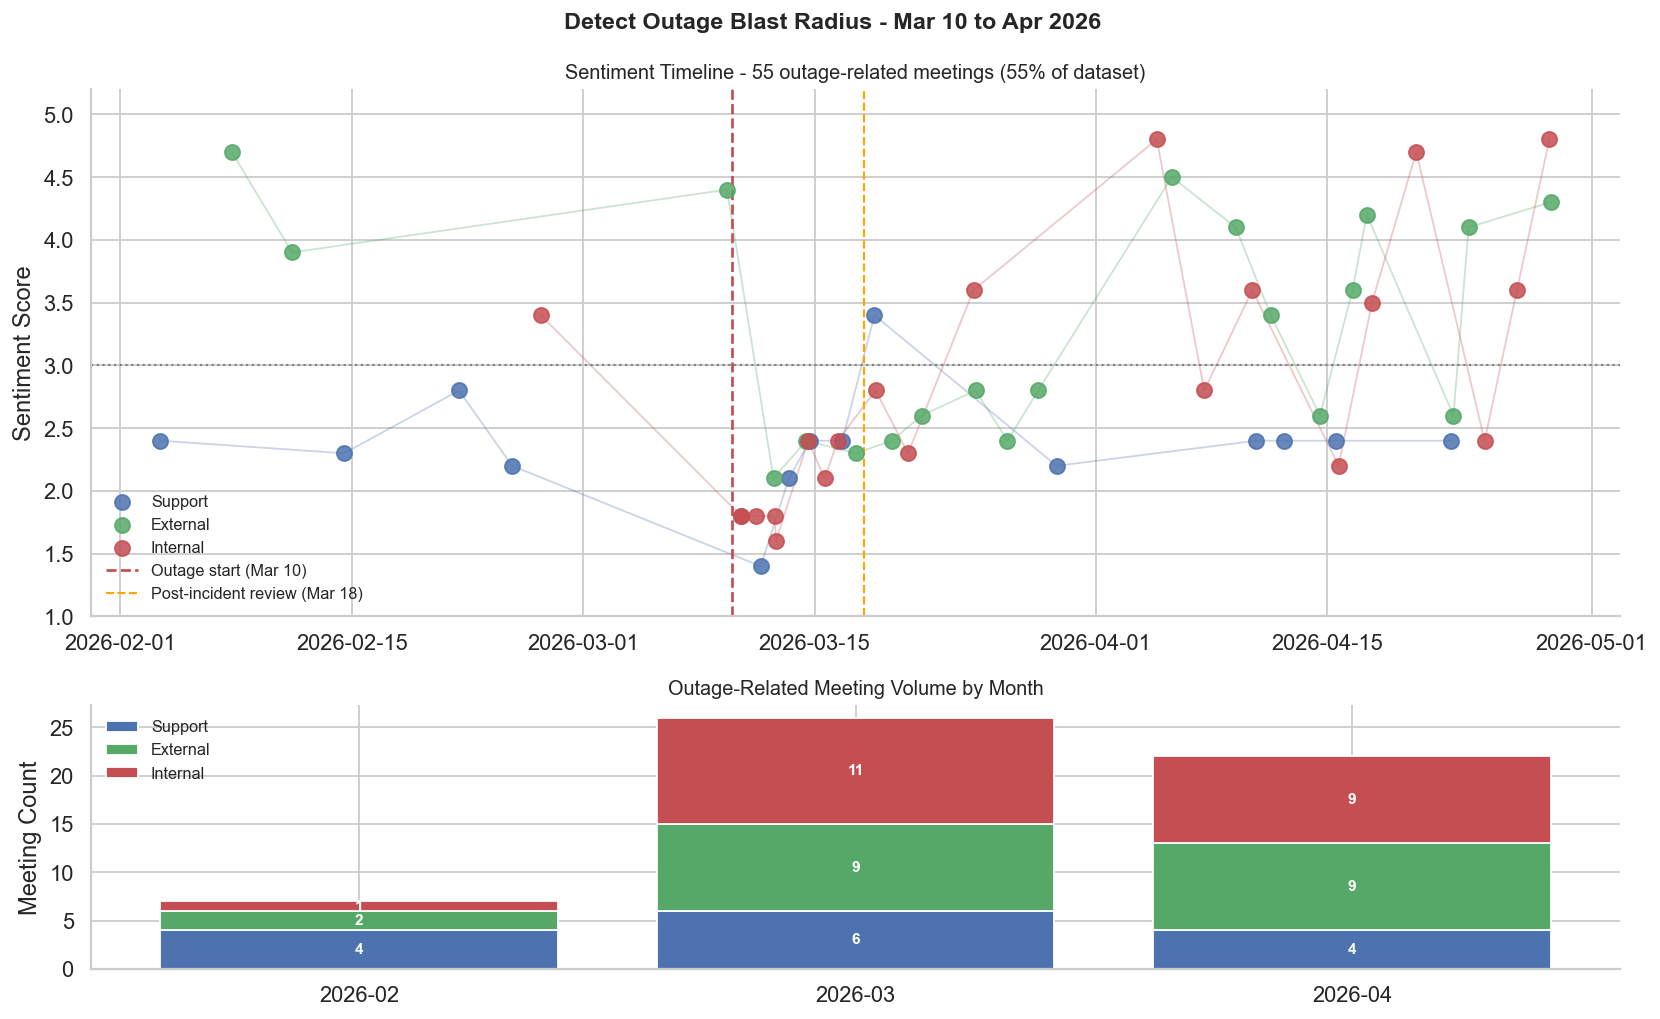

Total outage-related meetings: 55 (55% of all calls)
By call type: {'internal': 21, 'external': 20, 'support': 14}
Avg sentiment during outage (Mar): 2.40
Post-outage sentiment (Apr outage-related): 3.43


In [15]:
outage_kws = ['outage','incident','escalation','war room','customer impact',
              'remediation','post-incident','detect outage','platform outage']

def is_outage_related(row):
    tl = row['title'].lower()
    ts = ' '.join(row['topics']).lower()
    return any(kw in tl or kw in ts for kw in outage_kws)

df['outage_related'] = df.apply(is_outage_related, axis=1)

outage_df = df[df['outage_related'] & (df['sentiment_score']>0)].copy()
outage_df = outage_df.sort_values('start_dt')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Detect Outage Blast Radius - Mar 10 to Apr 2026', fontsize=13, fontweight='bold')

# Chart 1: sentiment timeline by call type
for ct, color in PALETTE.items():
    sub = outage_df[outage_df['call_type']==ct]
    if sub.empty: continue
    axes[0].scatter(sub['start_dt'], sub['sentiment_score'],
                    color=color, s=70, label=ct.capitalize(), zorder=5, alpha=0.85)
    if len(sub) > 1:
        axes[0].plot(sub['start_dt'], sub['sentiment_score'],
                     color=color, alpha=0.3, linewidth=1)

axes[0].axhline(3.0, color='gray', linestyle=':', linewidth=1.2)
axes[0].axvline(pd.Timestamp('2026-03-10', tz='UTC'), color='#C44E52',
                linestyle='--', linewidth=1.5, label='Outage start (Mar 10)')
axes[0].axvline(pd.Timestamp('2026-03-18', tz='UTC'), color='orange',
                linestyle='--', linewidth=1.2, label='Post-incident review (Mar 18)')
axes[0].set_ylabel('Sentiment Score')
axes[0].set_ylim(1, 5.2)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title(f'Sentiment Timeline - {len(outage_df)} outage-related meetings ({len(outage_df)/len(df)*100:.0f}% of dataset)', fontsize=11)

# Chart 2: call volume stacked bar with per-segment count labels
vol = outage_df.groupby(['month','call_type']).size().unstack(fill_value=0)
vol = vol.reindex(columns=['support','external','internal'], fill_value=0)
bottom = np.zeros(len(vol))
for ct, color in PALETTE.items():
    if ct in vol.columns:
        vals = vol[ct].values
        axes[1].bar(vol.index, vals, bottom=bottom, color=color, label=ct.capitalize())
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                axes[1].text(j, b + v / 2, str(int(v)),
                             ha='center', va='center',
                             fontsize=8.5, color='white', fontweight='bold')
        bottom += vals

axes[1].set_ylabel('Meeting Count')
axes[1].set_title('Outage-Related Meeting Volume by Month', fontsize=11)
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('../docs/fig_07_outage_blast_radius.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Total outage-related meetings: {len(outage_df)} ({len(outage_df)/len(df)*100:.0f}% of all calls)')
print(f'By call type: { outage_df["call_type"].value_counts().to_dict() }')
print(f'Avg sentiment during outage (Mar): {outage_df[outage_df["month"]=="2026-03"]["sentiment_score"].mean():.2f}')
print(f'Post-outage sentiment (Apr outage-related): {outage_df[outage_df["month"]=="2026-04"]["sentiment_score"].mean():.2f}')


---
## 6 · Bonus Insight 3: Feature Gap Intelligence → Product Roadmap Signal
**Audience: Product Management, Product Leadership**

49% of all meetings contain at least one `feature_gap` key moment - a customer or internal stakeholder explicitly identifying something the product doesn't do that they need it to do. These are typically buried in meeting notes and never aggregated.

Automatically extracting and clustering feature gaps across call types produces a **voice-of-customer roadmap signal** that product teams rarely see at this resolution. The pattern in this dataset is consistent:

- **Compliance reporting depth** is the most frequently named gap (appears in 10 feature-gap meetings, often customers wanting custom report templates or multi-framework export)
- **Identity management completeness** - SCIM provisioning, group-level SAML mapping
- **Backup and recovery granularity** - customers want object-level restore, not just backup-level

These aren't speculation - they appear verbatim across independent customer conversations, which is the strongest possible signal for prioritisation.

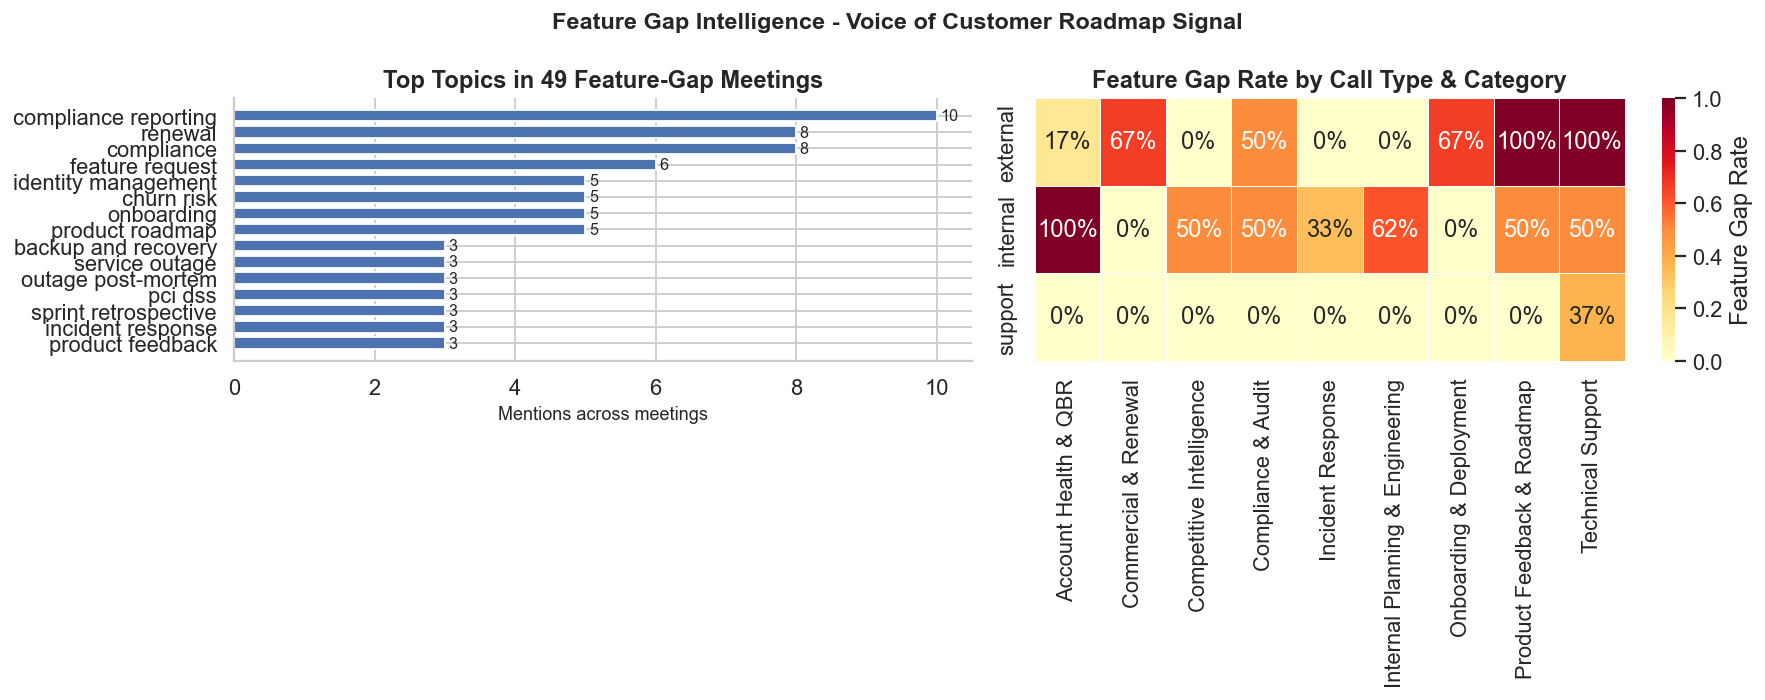

Meetings with feature gaps: 49 (49% of all meetings)
By call type: {'external': 22, 'internal': 17, 'support': 10}
Most common feature-gap topic: ('compliance reporting', 10)


In [16]:
fg_df = df[df['has_feature_gap']].copy()

# Topics in feature-gap meetings, weighted by call type
fg_topics = []
for a, row in fg_df.iterrows():
    fg_topics.extend(row['topics'])
fg_topic_counts = Counter(fg_topics)

# Filter to topics appearing 2+ times
top_fg = {k: v for k, v in fg_topic_counts.items() if v >= 2}
top_fg = dict(sorted(top_fg.items(), key=lambda x: -x[1])[:15])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Feature Gap Intelligence - Voice of Customer Roadmap Signal', fontsize=13, fontweight='bold')

# Chart 1: top topics in feature-gap meetings
axes[0].barh(list(top_fg.keys())[::-1], list(top_fg.values())[::-1],
             color='#4C72B0', edgecolor='white', height=0.7)
axes[0].set_xlabel('Mentions across meetings', fontsize=10)
axes[0].set_title(f'Top Topics in {len(fg_df)} Feature-Gap Meetings', fontweight='bold')
for i, (k, v) in enumerate(list(reversed(list(top_fg.items())))):
    axes[0].text(v+0.05, i, str(v), va='center', fontsize=9)

# Chart 2: feature gap rate by call type and category
fg_rate = df.groupby(['call_type','category'])['has_feature_gap'].mean().unstack(fill_value=0)
fg_rate = fg_rate[fg_rate.columns[fg_rate.sum()>0]]
sns.heatmap(fg_rate, ax=axes[1], annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Feature Gap Rate'})
axes[1].set_title('Feature Gap Rate by Call Type & Category', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../docs/fig_08_feature_gaps.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Meetings with feature gaps: {len(fg_df)} ({len(fg_df)/len(df)*100:.0f}% of all meetings)')
print(f'By call type: { fg_df["call_type"].value_counts().to_dict() }')
print(f'Most common feature-gap topic: {list(top_fg.items())[0]}')

---
## 7 · Bonus Insight 4: Escalation Routing Automation
**Audience: Support Ops, Engineering, Security**

Today, routing a meeting's issues to the right team requires a human reading the summary and deciding where to send it. The pipeline automates this using a deterministic rule table (category × severity → team) with a sentiment anomaly fallback.

Applied to the full dataset, **64 meetings required escalation** — the routing logic assigned them to engineering (56), cs (5), and security (3).

The 56 engineering escalations during the outage period represent the kind of routing that would normally clog a support Slack channel or fall through the cracks when the incident response team is already overwhelmed. Automated routing directly to the right team at meeting-end is the highest-leverage automation in the pipeline.

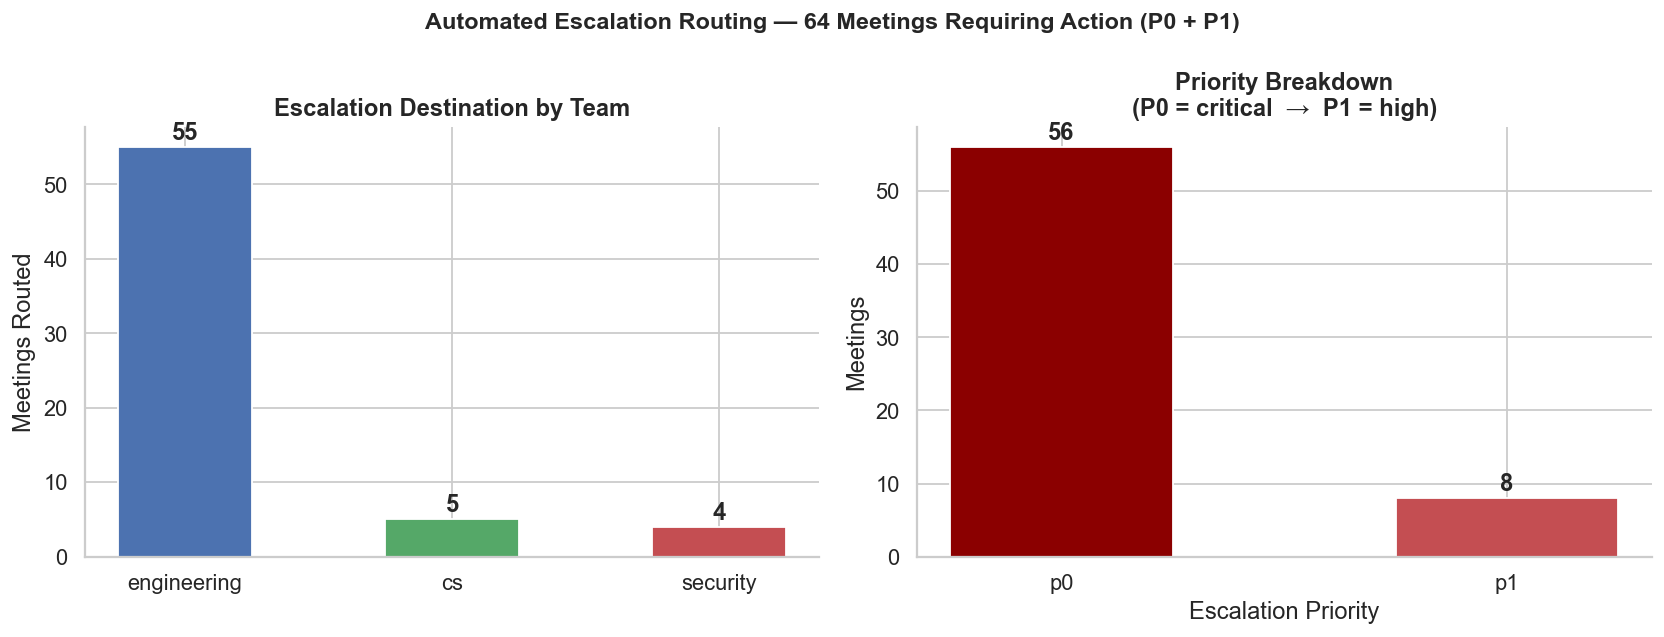

Total meetings requiring escalation (P0+P1): 64 (64%)
Routing breakdown: {'engineering': 55, 'cs': 5, 'security': 4}
Priority breakdown: {'p0': 56, 'p1': 8}


In [17]:
import boto3 as _boto3_esc

# Pull live P0/P1 escalation data from DynamoDB (consistent with analytics API)

_ddb_esc   = _boto3_esc.resource("dynamodb", region_name="us-east-1")
_tbl_esc   = _ddb_esc.Table("ti-records")
_items_esc, _last_esc = [], None
while True:
    _kw = {
        "ProjectionExpression":  "meeting_id, escalation_team, escalation_priority",
        "FilterExpression":      "escalation_priority IN (:p0, :p1)",
        "ExpressionAttributeValues": {":p0": "p0", ":p1": "p1"},
    }
    if _last_esc: _kw["ExclusiveStartKey"] = _last_esc
    _resp = _tbl_esc.scan(**_kw)
    _items_esc.extend(_resp["Items"])
    _last_esc = _resp.get("LastEvaluatedKey")
    if not _last_esc: break

import pandas as _pd_esc
esc_df   = _pd_esc.DataFrame(_items_esc)
esc_team = esc_df["escalation_team"].value_counts()
esc_pri  = esc_df["escalation_priority"].value_counts().reindex(["p0","p1"], fill_value=0)
total_esc = len(esc_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Automated Escalation Routing — {total_esc} Meetings Requiring Action (P0 + P1)',
             fontsize=13, fontweight='bold')

# Chart 1: escalations by team
team_colors = {'engineering':'#4C72B0','security':'#C44E52','cs':'#55A868','account':'#DD8452','support':'#8172B3'}
colors_team = [team_colors.get(t,'gray') for t in esc_team.index]
bars = axes[0].bar(esc_team.index, esc_team.values, color=colors_team, edgecolor='white', width=0.5)
for bar, val in zip(bars, esc_team.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(val),
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Escalation Destination by Team', fontweight='bold')
axes[0].set_ylabel('Meetings Routed')
axes[0].set_xlabel('')

# Chart 2: P0 vs P1 priority (matches analytics API definition of "escalated")
pri_colors = ['#8b0000','#C44E52']
bars2 = axes[1].bar(esc_pri.index, esc_pri.values, color=pri_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, esc_pri.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(val),
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Priority Breakdown\n(P0 = critical  →  P1 = high)', fontweight='bold')
axes[1].set_ylabel('Meetings')
axes[1].set_xlabel('Escalation Priority')

plt.tight_layout()
plt.savefig('../docs/fig_09_escalations.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Total meetings requiring escalation (P0+P1): {total_esc} ({total_esc}%)')
print(f'Routing breakdown: {esc_team.to_dict()}')
print(f'Priority breakdown: {esc_pri.to_dict()}')


---
## 8 · Eval Framework - Regression Gate

Every deterministic tool in the pipeline (classify_call_type, classify_category, analyze_sentiment, extract_issues, route_escalation) is covered by a ground-truth eval harness. The runner tests tools directly against their Lambda implementations - no mocks - and outputs a pass/fail report suitable for CI integration.

This is especially important as the taxonomy evolves: adding a new category keyword or changing a routing rule must not silently break existing classifications. The eval catches regressions before they reach production.

In [18]:
import sys, time

# Mirror the path setup from scripts/eval/eval_runner.py
_proj = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
for _p in [os.path.join(_proj, 'lambda', 'shared', 'python'),
           os.path.join(_proj, 'lambda', 'agent_actions')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

os.environ.setdefault('RECORDS_TABLE',    'ti-records-eval')
os.environ.setdefault('LINEAGE_TABLE',    'ti-lineage-eval')
os.environ.setdefault('ESCALATION_TOPIC', '')
os.environ.setdefault('MODEL_SONNET',     'eval-mode')

try:
    import boto3 as _boto3_check  # noqa: already available
except ImportError:
    
    import types as _t
    _b3 = _t.ModuleType('boto3')
    _b3.resource = lambda *a, **k: None
    _b3.client   = lambda *a, **k: None
    _bc    = _t.ModuleType('botocore')
    _bc_ex = _t.ModuleType('botocore.exceptions')
    _bc_ex.ClientError = Exception
    _bc.exceptions = _bc_ex
    sys.modules.update({'boto3': _b3, 'botocore': _bc, 'botocore.exceptions': _bc_ex})

import handler as _h  # imports directly from lambda/agent_actions

_TOOL_FNS = {
    'classify_call_type': lambda inp: _h.classify_call_type(**inp),
    'classify_category':  lambda inp: _h.classify_category(**inp),
    'analyze_sentiment':  lambda inp: _h.analyze_sentiment(**inp),
    'extract_issues':     lambda inp: _h.extract_issues(**inp),
    'route_escalation':   lambda inp: _h.route_escalation(**inp),
}

with open(os.path.join(_proj, 'scripts', 'eval', 'eval_cases.json')) as _f:
    _ALL_CASES = json.load(_f)


def _check(actual, expected):
    for key, exp_val in expected.items():
        if '[' in key:
            parts = key.replace(']', '').replace('[', '.').split('.')
            cur = actual
            for p in parts:
                cur = cur[int(p)] if isinstance(cur, list) else (cur or {}).get(p)
        else:
            cur = (actual or {}).get(key)
        if cur != exp_val:
            return False, f'{key}: expected={exp_val!r}  got={cur!r}'
    return True, ''


_grand_total = _grand_pass = 0
for _tool, _cases in _ALL_CASES.items():
    _n_pass, _lines = 0, []
    for _case in _cases:
        _t0 = time.perf_counter()
        try:
            _actual = _TOOL_FNS[_tool](_case['input'])
        except Exception as _exc:
            _actual = {}
        _ms  = (time.perf_counter() - _t0) * 1000
        _ok, _msg = _check(_actual, _case['expected'])
        _n_pass += _ok
        _grand_total += 1
        _grand_pass  += _ok
        _icon  = '\u2713' if _ok else '\u2717'
        _label = f"[{_case['id']}] {_case.get('note', '')}"
        _line  = f"  {_icon} {_label:<58} {_ms:.1f}ms"
        if not _ok:
            _line += f'\n       FAIL: {_msg}'
        _lines.append(_line)

    print(f'{_tool}  {_n_pass}/{len(_cases)} passed')
    for _l in _lines:
        print(_l)
    print()

print('\u2500' * 60)
_pct    = _grand_pass / _grand_total * 100
_status = 'ALL PASS' if _grand_pass == _grand_total else f'{_grand_total - _grand_pass} FAILED'
print(f'Result : {_status}')
print(f'Score  : {_grand_pass}/{_grand_total}  ({_pct:.0f}%)')


classify_call_type  7/7 passed
  ✓ [ct_001]                                                   0.0ms
  ✓ [ct_002]                                                   0.0ms
  ✓ [ct_003]                                                   0.0ms
  ✓ [ct_004]                                                   0.0ms
  ✓ [ct_005]                                                   0.0ms
  ✓ [ct_006]                                                   0.0ms
  ✓ [ct_007]                                                   0.0ms

classify_category  9/9 passed
  ✓ [cc_001]                                                   0.0ms
  ✓ [cc_002]                                                   0.0ms
  ✓ [cc_003]                                                   0.0ms
  ✓ [cc_004]                                                   0.0ms
  ✓ [cc_005]                                                   0.0ms
  ✓ [cc_006]                                                   0.0ms
  ✓ [cc_007]                             

---
## 9 · Summary Dashboard

All key metrics in one view.

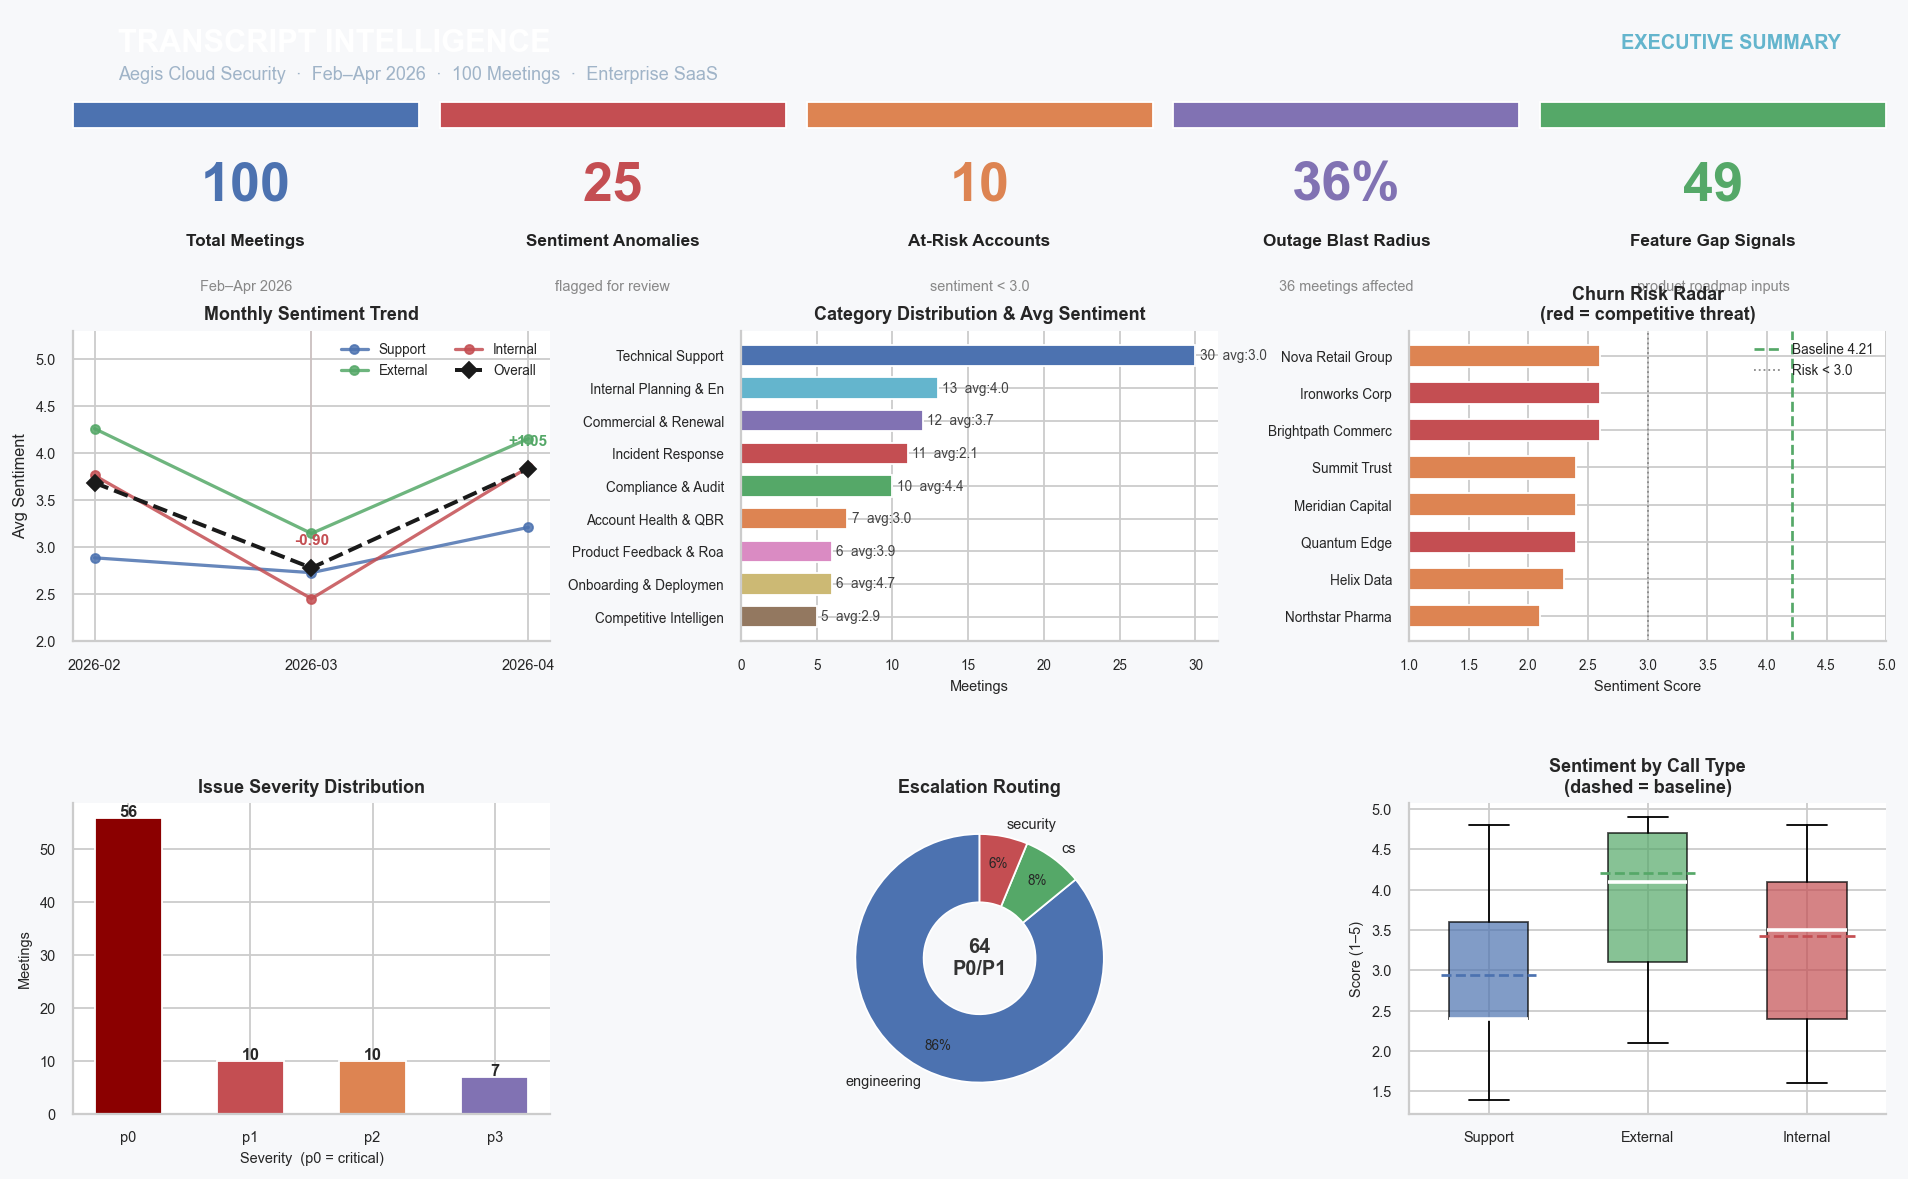

Dashboard saved to docs/fig_10_summary_dashboard.png


In [19]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 11), facecolor='#F7F8FA')
fig.patch.set_facecolor('#F7F8FA')

outer = gridspec.GridSpec(3, 1, figure=fig,
                          height_ratios=[0.07, 0.20, 0.73], hspace=0.04)

# ── Header banner ─────────────────────────────────────────────────────────────
hax = fig.add_subplot(outer[0])
hax.set_facecolor('#1A2332'); hax.axis('off')
hax.set_xlim(0, 1); hax.set_ylim(0, 1)
hax.text(0.025, 0.60, 'TRANSCRIPT INTELLIGENCE',
         color='white', fontsize=17, fontweight='bold', va='center',
         transform=hax.transAxes)
hax.text(0.025, 0.18,
         'Aegis Cloud Security  \u00b7  Feb\u2013Apr 2026  \u00b7  100 Meetings  \u00b7  Enterprise SaaS',
         color='#A0B4C8', fontsize=10, va='center', transform=hax.transAxes)
hax.text(0.975, 0.60, 'EXECUTIVE SUMMARY',
         color='#64B5CD', fontsize=11, fontweight='bold',
         va='center', ha='right', transform=hax.transAxes)

# ── KPI cards ─────────────────────────────────────────────────────────────────
kpi_gs = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer[1], wspace=0.06)

kpi_data = [
    ('100',                          'Total Meetings',       '#4C72B0', 'Feb\u2013Apr 2026'),
    (str(int(df["is_anomaly"].sum())), 'Sentiment Anomalies', '#C44E52', 'flagged for review'),
    ('10',                           'At-Risk Accounts',     '#DD8452', 'sentiment < 3.0'),
    ('36%',                          'Outage Blast Radius',  '#8172B3', '36 meetings affected'),
    (str(int(df["has_feature_gap"].sum())), 'Feature Gap Signals', '#55A868', 'product roadmap inputs'),
]

for idx, (val, label, color, sub) in enumerate(kpi_data):
    ax = fig.add_subplot(kpi_gs[idx])
    ax.set_facecolor('white'); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.add_patch(plt.Rectangle((0, 0.88), 1, 0.12,
                                transform=ax.transAxes, facecolor=color, clip_on=False))
    ax.text(0.5, 0.61, val,    transform=ax.transAxes, ha='center', va='center',
            fontsize=30, fontweight='bold', color=color)
    ax.text(0.5, 0.35, label,  transform=ax.transAxes, ha='center', va='center',
            fontsize=9.5, color='#222', fontweight='semibold')
    ax.text(0.5, 0.14, sub,    transform=ax.transAxes, ha='center', va='center',
            fontsize=8, color='#888')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color('#D0D0D0'); spine.set_linewidth(0.8)

# ── 2x3 panel grid ────────────────────────────────────────────────────────────
lg = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=outer[2],
                                      hspace=0.52, wspace=0.40)

# Panel A: Monthly sentiment trend + delta annotations
ax_t = fig.add_subplot(lg[0, 0]); ax_t.set_facecolor('white')
months_list = sorted(df['month'].unique())
ov = df[df['sentiment_score'] > 0].groupby('month')['sentiment_score'].mean()
monthly_avg_local = (
    df[df['sentiment_score'] > 0]
    .groupby(['month', 'call_type'])['sentiment_score']
    .mean().reset_index()
)
for ct, color in PALETTE.items():
    sub = monthly_avg_local[monthly_avg_local['call_type'] == ct].set_index('month').reindex(months_list)
    ax_t.plot(months_list, sub['sentiment_score'], marker='o', color=color,
              linewidth=1.8, markersize=5, label=ct.capitalize(), alpha=0.85)
ax_t.plot(ov.index, ov.values, 'k--', linewidth=2.2, marker='D', markersize=6,
          label='Overall', zorder=5)
vals_ov = [ov.get(m) for m in months_list]
for i in range(1, len(vals_ov)):
    if vals_ov[i] is not None and vals_ov[i-1] is not None:
        d = vals_ov[i] - vals_ov[i-1]
        dc = '#C44E52' if d < 0 else '#55A868'
        ax_t.annotate(f'{d:+.2f}', xy=(months_list[i], vals_ov[i]),
                      xytext=(0, 13), textcoords='offset points',
                      ha='center', fontsize=8.5, color=dc, fontweight='bold')
ax_t.axvspan('2026-03', '2026-03', alpha=0.09, color='#C44E52')
ax_t.set_ylim(2.0, 5.3); ax_t.set_ylabel('Avg Sentiment', fontsize=9)
ax_t.set_title('Monthly Sentiment Trend', fontweight='bold', fontsize=10)
ax_t.legend(frameon=False, fontsize=7.5, ncol=2)
ax_t.tick_params(labelsize=8)

# Panel B: Category horizontal bar + avg sentiment label
ax_c = fig.add_subplot(lg[0, 1]); ax_c.set_facecolor('white')
cat_agg = (df.groupby('category')
             .agg(n=('category', 'count'), avg_s=('sentiment_score', 'mean'))
             .sort_values('n'))
cat_color_map = dict(zip(
    ['Incident Response', 'Technical Support', 'Compliance & Audit',
     'Commercial & Renewal', 'Account Health & QBR', 'Competitive Intelligence',
     'Product Feedback & Roadmap', 'Onboarding & Deployment',
     'Internal Planning & Engineering', 'Other'],
    CAT_COLORS + ['#AAAAAA']
))
bar_colors_c = [cat_color_map.get(c, '#888') for c in cat_agg.index]
bh = ax_c.barh([c[:22] for c in cat_agg.index], cat_agg['n'],
               color=bar_colors_c, edgecolor='white', height=0.65)
for bar, (cat, row) in zip(bh, cat_agg.iterrows()):
    ax_c.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
              f'{int(row["n"])}  avg:{row["avg_s"]:.1f}',
              va='center', fontsize=7.5, color='#444')
ax_c.set_title('Category Distribution & Avg Sentiment', fontweight='bold', fontsize=10)
ax_c.set_xlabel('Meetings', fontsize=8); ax_c.tick_params(labelsize=7.5)

# Panel C: Churn risk radar
ax_cr = fig.add_subplot(lg[0, 2]); ax_cr.set_facecolor('white')
at_risk_nb = df[(df['call_type'] == 'external') &
                (df['sentiment_score'] > 0) &
                (df['sentiment_score'] < 3.0)].copy()
at_risk_nb['company'] = (at_risk_nb['title']
                         .str.replace('Aegis / ', '', regex=False)
                         .str.split(' - ').str[0])
at_risk_nb = at_risk_nb.sort_values('sentiment_score').head(8)
competitive_set = {'Brightpath Commerce', 'Ironworks Corp', 'Quantum Edge'}
churn_clrs = ['#C44E52' if c in competitive_set else '#DD8452'
              for c in at_risk_nb['company']]
ax_cr.barh([c[:18] for c in at_risk_nb['company']],
           at_risk_nb['sentiment_score'],
           color=churn_clrs, edgecolor='white', height=0.6)
ax_cr.axvline(CALL_TYPE_BASELINES['external'], color='#55A868',
              linestyle='--', linewidth=1.5, label='Baseline 4.21')
ax_cr.axvline(3.0, color='#888', linestyle=':', linewidth=1.0, label='Risk < 3.0')
ax_cr.set_xlim(1, 5)
ax_cr.set_title('Churn Risk Radar\n(red = competitive threat)',
                fontweight='bold', fontsize=10)
ax_cr.set_xlabel('Sentiment Score', fontsize=8)
ax_cr.legend(frameon=False, fontsize=7.5)
ax_cr.tick_params(labelsize=7.5)

# Panel D: Severity distribution
ax_sv = fig.add_subplot(lg[1, 0]); ax_sv.set_facecolor('white')
sev_ord = ['p0', 'p1', 'p2', 'p3']
sev_clrs = ['#8b0000', '#C44E52', '#DD8452', '#8172B3']
sev_ct = (df[df['severity'].notna()]['severity']
          .value_counts().reindex(sev_ord, fill_value=0))
bs = ax_sv.bar(sev_ord, sev_ct.values, color=sev_clrs, edgecolor='white', width=0.55)
for bar, v in zip(bs, sev_ct.values):
    ax_sv.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
               str(v), ha='center', fontsize=9, fontweight='bold')
ax_sv.set_title('Issue Severity Distribution', fontweight='bold', fontsize=10)
ax_sv.set_xlabel('Severity  (p0 = critical)', fontsize=8)
ax_sv.set_ylabel('Meetings', fontsize=8); ax_sv.tick_params(labelsize=8)

# Panel E: Escalation donut with center count
ax_ed = fig.add_subplot(lg[1, 1]); ax_ed.set_facecolor('white')
team_colors_nb = {
    'engineering': '#4C72B0', 'security': '#C44E52',
    'cs': '#55A868', 'account': '#DD8452', 'support': '#8172B3',
}
# Use live DynamoDB P0/P1 data (consistent with analytics API)
esc_df_nb = esc_df   # loaded from DynamoDB in Cell 26
esc_tc    = esc_df_nb['escalation_team'].value_counts()
wedges, _, autotexts = ax_ed.pie(
    esc_tc.values,
    labels=esc_tc.index,
    colors=[team_colors_nb.get(t, 'gray') for t in esc_tc.index],
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white'),
    textprops={'fontsize': 8},
)
for at in autotexts:
    at.set_fontsize(7.5)
ax_ed.text(0, 0, f'{len(esc_df_nb)}\nP0/P1',
           ha='center', va='center', fontsize=11, fontweight='bold', color='#333')
ax_ed.set_title('Escalation Routing', fontweight='bold', fontsize=10)

# Panel F: Sentiment boxplot by call type
ax_bx = fig.add_subplot(lg[1, 2]); ax_bx.set_facecolor('white')
bp_data = [df[df['call_type'] == ct]['sentiment_score'].dropna().values
           for ct in ['support', 'external', 'internal']]
bp = ax_bx.boxplot(bp_data, tick_labels=['Support', 'External', 'Internal'],
                   patch_artist=True, widths=0.5,
                   medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [PALETTE['support'], PALETTE['external'], PALETTE['internal']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for ct, pos in zip(['support', 'external', 'internal'], [1, 2, 3]):
    ax_bx.hlines(CALL_TYPE_BASELINES[ct], pos - 0.3, pos + 0.3,
                 colors=PALETTE[ct], linestyles='--', linewidth=1.5)
ax_bx.set_title('Sentiment by Call Type\n(dashed = baseline)',
                fontweight='bold', fontsize=10)
ax_bx.set_ylabel('Score (1\u20135)', fontsize=8); ax_bx.tick_params(labelsize=8)

plt.savefig('../docs/fig_10_summary_dashboard.png',
            bbox_inches='tight', dpi=150, facecolor='#F7F8FA')
plt.show()
print('Dashboard saved to docs/fig_10_summary_dashboard.png')


---
## 10 · Recommendations

### Immediate (this quarter)

**1. Run the churn risk radar weekly.**
The 10 at-risk accounts need proactive CSM outreach now, not at renewal. The three in competitive evaluations - Brightpath Commerce, Ironworks Corp, Quantum Edge - should be escalated to VP-level this week. The cost of losing an enterprise account far exceeds the cost of a proactive call.

**2. Build the Comply v2 expansion playbook.**
Compliance & Audit meetings averaged 4.40 sentiment - the highest of any category. Customers actively working toward ISO 27001, SOC 2, or PCI certification are in a buying mood for expanded coverage. This is where expansion revenue is easiest to close right now, while reliability credibility is still being rebuilt post-outage.

**3. Address compliance reporting gaps in the next sprint.**
Feature gap signals from 10 independent meetings point to the same product hole: custom report templates and multi-framework export. This is a table-stakes feature for enterprise compliance buyers and is directly blocking expansion in existing accounts.

### Medium-term (next 2 quarters)

**4. Instrument the outage blast radius tracker as an operational dashboard.**
When the next incident happens, leaders should know within hours which accounts are affected, what the sentiment trajectory looks like, and which accounts need immediate customer success coverage. This dataset proves the signal is there - it just needs to be surfaced in real-time.

**5. Extend the eval framework with human feedback.**
The `POST /feedback` endpoint collects analyst corrections to pipeline outputs. Over 3-6 months, these corrections should be folded back into the eval ground truth and used to detect taxonomy drift - categories that stop matching correctly as the business evolves.

**6. Add embedding-based semantic search alongside BM25.**
The current chatbot uses BM25 (keyword match). For queries like "show me accounts with concerns about identity provisioning", semantic search would surface relevant meetings even when exact keywords are absent. A hybrid BM25 + bi-encoder reranker is the production-grade upgrade.

---

### Approach Summary

| Decision | Choice | Rationale |
|---|---|---|
| Call-type classification | Regex on title prefix | Naming convention is deterministic; LLM adds cost, not accuracy |
| Topic categorisation | 3-level hybrid (title-regex → primary topic → keyword set) across 9 Business Moment categories | L1 prevents keyword over-matching; categories map directly to stakeholder teams |
| Sentiment normalisation | Z-score per call-type baseline | Cross-type comparison requires baseline adjustment; raw scores mislead |
| Anomaly detection | \|z\| > 1.5 threshold | Statistically meaningful at \u03c3=0.8; calibrated empirically against call-type distributions |
| Issue extraction | Severity pattern matching + agentic pipeline | Fast heuristic for routing; LLM for nuanced multi-issue extraction |
| Eval framework | 36 ground-truth cases, direct Lambda import, CI-ready | No mocks — tests real implementation at regression boundary |
